In [1]:
# =========================
# CÉLULA 1 — Imports & Config
# =========================
import os
import re
import glob
import json
import hashlib
import unicodedata
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import pandas as pd
import numpy as np

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 80)

# >>> AJUSTE AQUI <<<
DATA_DIR = r"C:\Users\nasci\Documentos\doutorado-praticas\Redes Complexas\LGBTfobia\datasets"  # pasta com os 6 arquivos
DIC_PATH = r"C:\Users\nasci\Documentos\doutorado-praticas\Redes Complexas\LGBTfobia\Prejudice\v2_SocialLIWC_formatado_ordenado (2).dic"

# Se seus arquivos forem .csv, perfeito. Se forem .xlsx, .json, .parquet, também funciona.
FILES_HINT = [
    "dataset_zap_1",
    "dataset_zap_2",
    "telegram_dataset_01",
    "telegram_dataset_02",
]

print("DATA_DIR:", DATA_DIR)
print("DIC_PATH:", DIC_PATH)

DATA_DIR: C:\Users\nasci\Documentos\doutorado-praticas\Redes Complexas\LGBTfobia\datasets
DIC_PATH: C:\Users\nasci\Documentos\doutorado-praticas\Redes Complexas\LGBTfobia\Prejudice\v2_SocialLIWC_formatado_ordenado (2).dic


In [2]:
# =========================
# CÉLULA 2 — Localiza arquivos (independente da extensão)
# =========================
def find_file_by_hint(data_dir: str, hint: str) -> Optional[str]:
    # procura por qualquer extensão comum
    patterns = [
        os.path.join(data_dir, hint + ".*"),
        os.path.join(data_dir, hint.replace(" ", "_") + ".*"),
        os.path.join(data_dir, hint.replace("_", " ") + ".*"),
    ]
    matches = []
    for p in patterns:
        matches.extend(glob.glob(p))
    # remove duplicados
    matches = sorted(list(set(matches)))
    return matches[0] if matches else None

found_files = {}
missing = []
for hint in FILES_HINT:
    fp = find_file_by_hint(DATA_DIR, hint)
    if fp is None:
        missing.append(hint)
    else:
        found_files[hint] = fp

print("Arquivos encontrados:")
for k, v in found_files.items():
    print(f" - {k}: {v}")

if missing:
    print("\n⚠️ Não encontrei estes (talvez o nome esteja diferente):")
    for m in missing:
        print(" -", m)

Arquivos encontrados:
 - dataset_zap_1: C:\Users\nasci\Documentos\doutorado-praticas\Redes Complexas\LGBTfobia\datasets\dataset_zap_1.csv
 - dataset_zap_2: C:\Users\nasci\Documentos\doutorado-praticas\Redes Complexas\LGBTfobia\datasets\dataset_zap_2.csv
 - telegram_dataset_01: C:\Users\nasci\Documentos\doutorado-praticas\Redes Complexas\LGBTfobia\datasets\telegram_dataset_01.csv
 - telegram_dataset_02: C:\Users\nasci\Documentos\doutorado-praticas\Redes Complexas\LGBTfobia\datasets\telegram_dataset_02.csv


In [3]:
# =========================
# CÉLULA A — Recarregar os 6 datasets e guardar em dfs
# =========================
import os, glob
from pathlib import Path
import pandas as pd

DATA_DIR = r"C:\Users\nasci\Documentos\doutorado-praticas\Redes Complexas\LGBTfobia\datasets"

FILES_HINT = [
    "dataset_zap_1",
    "dataset_zap_2",
    "telegram_dataset_01",
    "telegram_dataset_02",
]

def find_file_by_hint(data_dir: str, hint: str):
    patterns = [
        os.path.join(data_dir, hint + ".*"),
        os.path.join(data_dir, hint.replace(" ", "_") + ".*"),
        os.path.join(data_dir, hint.replace("_", " ") + ".*"),
    ]
    matches = []
    for p in patterns:
        matches.extend(glob.glob(p))
    matches = sorted(list(set(matches)))
    return matches[0] if matches else None

def read_any(path: str) -> pd.DataFrame:
    ext = Path(path).suffix.lower()
    if ext in [".csv", ".tsv"]:
        sep = "\t" if ext == ".tsv" else ","
        for enc in ["utf-8", "utf-8-sig", "latin1"]:
            try:
                return pd.read_csv(path, sep=sep, encoding=enc, low_memory=False)
            except Exception:
                pass
        return pd.read_csv(path, sep=sep, low_memory=False)
    elif ext in [".xlsx", ".xls"]:
        return pd.read_excel(path)
    elif ext in [".json"]:
        try:
            return pd.read_json(path, lines=True)
        except Exception:
            return pd.read_json(path)
    elif ext in [".parquet"]:
        return pd.read_parquet(path)
    else:
        raise ValueError(f"Extensão não suportada: {ext} ({path})")

found_files = {}
for hint in FILES_HINT:
    fp = find_file_by_hint(DATA_DIR, hint)
    if fp is None:
        raise FileNotFoundError(f"Não encontrei arquivo para: {hint} dentro de {DATA_DIR}")
    found_files[hint] = fp

dfs = []
for hint, fp in found_files.items():
    df = read_any(fp)
    df["dataset_name"] = hint
    df["source_file"] = fp
    dfs.append(df)

print("Datasets carregados:", len(dfs))
for i, df in enumerate(dfs):
    print(f"[{i}] {df['dataset_name'].iloc[0]} -> shape={df.shape}")

Datasets carregados: 4
[0] dataset_zap_1 -> shape=(631150, 35)
[1] dataset_zap_2 -> shape=(549143, 35)
[2] telegram_dataset_01 -> shape=(804436, 21)
[3] telegram_dataset_02 -> shape=(992594, 21)


In [4]:
# =========================
# CÉLULA B — Padronizar cada DF e criar base unificada (define "base")
# =========================
import numpy as np

def standardize(df: pd.DataFrame) -> pd.DataFrame:
    # 1) tenta schema "grande" (35/21 colunas)
    if "text_content_anonymous" in df.columns and "id_member_anonymous" in df.columns:
        out = pd.DataFrame()
        out["dataset_name"] = df["dataset_name"].astype(str)
        out["source_file"] = df["source_file"].astype(str)

        out["text_raw"] = df["text_content_anonymous"].astype(str)
        out["user_id"]  = df["id_member_anonymous"].astype(str)
        out["group_id"] = df.get("id_group_anonymous", "").astype(str)
        out["timestamp"] = pd.to_datetime(df.get("date_message", pd.NaT), errors="coerce")

        if "messenger" in df.columns:
            out["platform"] = df["messenger"].astype(str).str.lower().str.strip()
        else:
            # fallback por nome
            nm = out["dataset_name"].iloc[0].lower()
            out["platform"] = "whatsapp" if "zap" in nm or "whatsapp" in nm else ("telegram" if "telegram" in nm else "unknown")

        return out

    # 2) schema "pequeno" (3000, 4 colunas) — tenta achar um texto por heurística
    # (ajustamos depois se você colar as colunas exatas)
    text_candidates = [c for c in df.columns if "text" in c.lower() or "message" in c.lower() or "mens" in c.lower()]
    user_candidates = [c for c in df.columns if "user" in c.lower() or "member" in c.lower() or "autor" in c.lower()]
    date_candidates = [c for c in df.columns if "date" in c.lower() or "time" in c.lower() or "data" in c.lower()]

    text_col = text_candidates[0] if text_candidates else df.columns[-1]
    user_col = user_candidates[0] if user_candidates else df.columns[0]
    date_col = date_candidates[0] if date_candidates else None

    out = pd.DataFrame()
    out["dataset_name"] = df["dataset_name"].astype(str)
    out["source_file"] = df["source_file"].astype(str)

    out["text_raw"] = df[text_col].astype(str)
    out["user_id"] = df[user_col].astype(str)
    out["group_id"] = ""
    out["timestamp"] = pd.to_datetime(df[date_col], errors="coerce") if date_col else pd.NaT

    nm = out["dataset_name"].iloc[0].lower()
    out["platform"] = "whatsapp" if "zap" in nm or "whatsapp" in nm else ("telegram" if "telegram" in nm else "unknown")
    return out

std_dfs = [standardize(df) for df in dfs]
base = pd.concat(std_dfs, ignore_index=True)

print("✅ base criada:", base.shape)
base.head(3)

✅ base criada: (2977323, 7)


,dataset_name,source_file,text_raw,user_id,group_id,timestamp,platform
0,dataset_zap_1,C:\Users\nasci\Documentos\doutorado-praticas\Redes Complexas\LGBTfobia\datasets\dataset_zap_1.csv,👆 *O PIB DECOLA NOVAMENTE!*\n\n*O Ministério da Economia elevou nesta quinta-feira (15) a projeção de crescimento do...,cd45e9e743ddcb9a94f61619300539a9,b14e237b7d02b836a57692bd2d8fec88,2022-09-15 17:59:00,whatsapp
1,dataset_zap_1,C:\Users\nasci\Documentos\doutorado-praticas\Redes Complexas\LGBTfobia\datasets\dataset_zap_1.csv,👆 *O PIB DECOLA NOVAMENTE!*\n\n*O Ministério da Economia elevou nesta quinta-feira (15) a projeção de crescimento do...,cd45e9e743ddcb9a94f61619300539a9,6fb204781074ea35ab1e957ba150c56f,2022-09-15 17:59:04,whatsapp
2,dataset_zap_1,C:\Users\nasci\Documentos\doutorado-praticas\Redes Complexas\LGBTfobia\datasets\dataset_zap_1.csv,nan,ca191ceb779cd4f7c0519ca5208f3d13,46df46ae5f1bf2efb185d3828e92263d,2022-08-18 22:33:45,nan


In [5]:
# =========================
# CÉLULA C — Verificação rápida (pra não cair de novo)
# =========================
assert "base" in globals(), "base ainda não existe!"
print("OK: base existe.")
print(base[["dataset_name","platform","user_id","group_id","timestamp","text_raw"]].head(5))

OK: base existe.
    dataset_name  platform                           user_id  \
0  dataset_zap_1  whatsapp  cd45e9e743ddcb9a94f61619300539a9   
1  dataset_zap_1  whatsapp  cd45e9e743ddcb9a94f61619300539a9   
2  dataset_zap_1       nan  ca191ceb779cd4f7c0519ca5208f3d13   
3  dataset_zap_1  whatsapp  78539530199651468e919e1660f1f419   
4  dataset_zap_1  whatsapp  a49364c6471d2f90e20e45386772c7b0   

                           group_id           timestamp  \
0  b14e237b7d02b836a57692bd2d8fec88 2022-09-15 17:59:00   
1  6fb204781074ea35ab1e957ba150c56f 2022-09-15 17:59:04   
2  46df46ae5f1bf2efb185d3828e92263d 2022-08-18 22:33:45   
3  39b271ec422f6c11db3159df72078c6c 2022-09-15 17:59:10   
4  5997ae10965a21be6f4bb47de3e243ae 2022-09-15 17:59:12   

                                                                                                                  text_raw  
0  👆 *O PIB DECOLA NOVAMENTE!*\n\n*O Ministério da Economia elevou nesta quinta-feira (15) a projeção de crescimento d

In [6]:
def standardize_known_schema(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame()
    out["dataset_name"] = df.get("dataset_name", "unknown").astype(str)
    out["source_file"] = df.get("source_file", "unknown").astype(str)

    # schema que você mostrou
    out["text_raw"] = df["text_content_anonymous"].astype(str)
    out["user_id"]  = df["id_member_anonymous"].astype(str)
    out["group_id"] = df["id_group_anonymous"].astype(str)
    out["timestamp"] = pd.to_datetime(df["date_message"], errors="coerce")

    # messenger -> platform
    if "messenger" in df.columns:
        out["platform"] = df["messenger"].astype(str).str.lower().str.strip()
        out["platform"] = out["platform"].replace({
            "whatsapp": "whatsapp",
            "telegram": "telegram",
            "wpp": "whatsapp",
            "tg": "telegram"
        })
    else:
        out["platform"] = "unknown"

    return out

In [7]:
import re
import string
import emoji
import nltk
from urllib.parse import urlparse
from nltk.corpus import stopwords

# downloads
try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt")

try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    nltk.download("stopwords")

# ============
# (1) LIXO / SPAM / TRAVA
# ============
crash_keywords = [
    "trava", "crash", "binario", "destrava", "imune", "rajada", 
    "virus", "clonagem", "hacker", "phoenix", "revaneio", "alien_monster", 
    "࿗", "꙰", "\u202e", "bòsta nà", "caráê",
    "auto entitula logan", "raimundo",
    "harbyngers", "fish", "crown", "sun"
]

spam_keywords = [
    "limpar nome", "aumentar score", "cnpj", "crédito", "empréstimo", 
    "venda", "oferta", "desconto", "turismo", "excursão", "saída", 
    "ganhe", "oportunidade", "renda extra", "marketing", "consórcio",
    "delivery", "entregamos", "promoção",
    "iptv", "tv box", "hbo", "telecine", 
    "internet ilimitada", "sem travamentos",
    "kwai", "kwaivideocom"
]

custom_stopwords = {
    "bom", "dia", "boa", "tarde", "noite", "olá", "oi", "ola", "tchau",
    "kk", "kkk", "kkkk", "kkkkk", "rs", "rsrs", "aff", "eita", "oxi", "oxe",
    "imagem", "figura", "sticker", "áudio", "audio", "vídeo", "video",
    "mensagem", "encaminhada", "apagou", "pra", "pro", "tá", "pq", "vc"
}

stop_words_total = set(stopwords.words("portuguese")).union(custom_stopwords)

def is_junk_message(text_lower: str) -> bool:
    if len(text_lower) > 3000:
        return True
    if any(term in text_lower for term in crash_keywords):
        return True
    if any(term in text_lower for term in spam_keywords):
        return True
    return False

def simplify_urls(text: str) -> str:
    url_pattern = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)

    def extract_domain(match):
        url = match.group(0)
        if not url.startswith("http"):
            url = "http://" + url
        try:
            parsed = urlparse(url)
            domain = parsed.netloc.replace("www.", "")
            return domain
        except:
            return match.group(0)

    return url_pattern.sub(extract_domain, text)

# (2) normalização leve (para Prejudice)
import unicodedata
WS_RE = re.compile(r"\s+")
PUNCT_RE = re.compile(r"[^\w\s]", re.UNICODE)

def strip_accents(s: str) -> str:
    s = unicodedata.normalize("NFD", s)
    s = "".join(ch for ch in s if unicodedata.category(ch) != "Mn")
    return unicodedata.normalize("NFC", s)

def norm_basic(text: str) -> str:
    if not isinstance(text, str):
        return ""
    t = text.lower()
    if is_junk_message(t):
        return ""  # já mata lixo aqui
    t = simplify_urls(t)
    t = strip_accents(t)
    t = t.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    t = PUNCT_RE.sub(" ", t)
    t = WS_RE.sub(" ", t).strip()
    return t

# aplica na base unificada
base["text_norm_basic"] = base["text_raw"].apply(norm_basic)
base = base[base["text_norm_basic"].str.len() > 0].copy()

base[["text_raw","text_norm_basic"]].head(3)

,text_raw,text_norm_basic
0,👆 *O PIB DECOLA NOVAMENTE!*\n\n*O Ministério da Economia elevou nesta quinta-feira (15) a projeção de crescimento do...,o pib decola novamente o ministerio da economia elevou nesta quinta feira 15 a projecao de crescimento do produto in...
1,👆 *O PIB DECOLA NOVAMENTE!*\n\n*O Ministério da Economia elevou nesta quinta-feira (15) a projeção de crescimento do...,o pib decola novamente o ministerio da economia elevou nesta quinta feira 15 a projecao de crescimento do produto in...
2,nan,nan


In [8]:
def preprocess_text_final(text: str) -> List[str]:
    if not isinstance(text, str):
        return []
    text_lower = text.lower()
    if is_junk_message(text_lower):
        return []

    # mantém domínios
    text = simplify_urls(text)

    # emoji -> tokens tipo :angry:
    text = emoji.demojize(text)

    # remove pontuação antes de tokenizar
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = nltk.word_tokenize(text.lower())

    tokens_clean = []
    for tok in tokens:
        if tok in stop_words_total:
            continue
        if len(tok) < 2:
            continue
        tokens_clean.append(tok)
    return tokens_clean

# cria tokens + regra >=2
from tqdm.auto import tqdm
tqdm.pandas()

base["tokens_preprocessed"] = base["text_raw"].progress_apply(preprocess_text_final)
base = base[base["tokens_preprocessed"].map(len) >= 2].copy()

base["clean_text"] = base["tokens_preprocessed"].apply(lambda x: " ".join(x))
base = base.reset_index(drop=True)

base[["clean_text","tokens_preprocessed"]].head(3)

  0%|          | 0/2863276 [00:00<?, ?it/s]

,clean_text,tokens_preprocessed
0,backhandindexpointingup pib decola novamente ministério economia elevou nesta quintafeira 15 projeção crescimento pr...,"[backhandindexpointingup, pib, decola, novamente, ministério, economia, elevou, nesta, quintafeira, 15, projeção, cr..."
1,backhandindexpointingup pib decola novamente ministério economia elevou nesta quintafeira 15 projeção crescimento pr...,"[backhandindexpointingup, pib, decola, novamente, ministério, economia, elevou, nesta, quintafeira, 15, projeção, cr..."
2,urgente pesquisa brasmarket aponta vitória bolsonaro primeiro turno terrabrasilnoticiascom,"[urgente, pesquisa, brasmarket, aponta, vitória, bolsonaro, primeiro, turno, terrabrasilnoticiascom]"


In [9]:
import re
EMOJI_TOKEN_RE = re.compile(r"^[a-z0-9_]+$")  # tokens do demojize geralmente ficam assim

def reduce_repeated_tokens(tokens, max_rep=2):
    out = []
    last = None
    rep = 0
    for t in tokens:
        if t == last:
            rep += 1
        else:
            last = t
            rep = 1
        if rep <= max_rep:
            out.append(t)
    return out

# aplica só nos tokens, depois refaz clean_text
base["tokens_preprocessed"] = base["tokens_preprocessed"].apply(lambda toks: reduce_repeated_tokens(toks, max_rep=2))
base["clean_text"] = base["tokens_preprocessed"].apply(lambda x: " ".join(x))

In [10]:
# normalização leve (para matching do dicionário)
import unicodedata, re

URL_RE = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
WS_RE = re.compile(r"\s+")
PUNCT_RE = re.compile(r"[^\w\s]", re.UNICODE)

def strip_accents(s: str) -> str:
    s = unicodedata.normalize("NFD", s)
    s = "".join(ch for ch in s if unicodedata.category(ch) != "Mn")
    return unicodedata.normalize("NFC", s)

def norm_basic(text: str) -> str:
    if not isinstance(text, str):
        return ""
    t = text.lower()
    t = URL_RE.sub(" ", t)
    t = strip_accents(t)
    t = t.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    t = PUNCT_RE.sub(" ", t)
    t = WS_RE.sub(" ", t).strip()
    return t

base["text_norm_basic"] = base["text_raw"].apply(norm_basic)

In [11]:
from pathlib import Path
import re

DIC_PATH = r"C:\Users\nasci\Documentos\doutorado-praticas\Redes Complexas\LGBTfobia\Prejudice\v2_SocialLIWC_formatado_ordenado (2).dic"

def parse_liwc_dic(dic_path: str):
    categories = {}
    terms = []
    with open(dic_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [ln.strip() for ln in f.readlines()]

    section = 0
    for ln in lines:
        if not ln:
            continue
        if ln.startswith("%"):
            section += 1
            continue
        parts = ln.split()
        if section == 1:
            try:
                cid = int(parts[0])
                cname = " ".join(parts[1:])
                categories[cid] = cname
            except:
                pass
        elif section >= 2:
            term = parts[0]
            ids = []
            for p in parts[1:]:
                try:
                    ids.append(int(p))
                except:
                    pass
            if ids:
                terms.append((term, ids))
    return categories, terms

categories, terms = parse_liwc_dic(DIC_PATH)

# acha id LGBTfobia
target_name = "lgbtfobia"
target_ids = [cid for cid, name in categories.items() if name.lower() == target_name]
if not target_ids:
    target_ids = [cid for cid, name in categories.items() if target_name in name.lower()]
LGB_ID = target_ids[0]
print("ID LGBTfobia:", LGB_ID, "->", categories[LGB_ID])

# termos LGBT
lgb_terms = [term for term, ids in terms if LGB_ID in ids]

def term_to_regex(term: str) -> str:
    if term.endswith("*"):
        prefix = re.escape(term[:-1])
        return rf"\b{prefix}\w*\b"
    return rf"\b{re.escape(term)}\b"

lgb_regex = re.compile("|".join(term_to_regex(t) for t in lgb_terms), flags=re.IGNORECASE)

mask_lgb = base["text_norm_basic"].apply(lambda x: bool(lgb_regex.search(x)))
lgb_df = base.loc[mask_lgb].copy()

print("Linhas com LGBTfobia:", len(lgb_df))
lgb_df[["platform","dataset_name","text_raw"]].head(5)

ID LGBTfobia: 4 -> LGBTFobia
Linhas com LGBTfobia: 8468


,platform,dataset_name,text_raw
398,whatsapp,dataset_zap_1,"Eu tô sabendo\nEu tô sabendo muito bem o que o senhor fez com a minha esposa\nE agora o senhor vai pagar, viu? (cala..."
426,whatsapp,dataset_zap_1,*MUNDO: ATAQUE IDEOLÓGICO ÀS CRIANÇAS DO CHILE CAUSA PERPLEXIDADE COM PROFESSORA SIMULANDO CASAMENTO GAY INFANTIL; A...
427,whatsapp,dataset_zap_1,*MUNDO: ATAQUE IDEOLÓGICO ÀS CRIANÇAS DO CHILE CAUSA PERPLEXIDADE COM PROFESSORA SIMULANDO CASAMENTO GAY INFANTIL; A...
435,whatsapp,dataset_zap_1,*MUNDO: ATAQUE IDEOLÓGICO ÀS CRIANÇAS DO CHILE CAUSA PERPLEXIDADE COM PROFESSORA SIMULANDO CASAMENTO GAY INFANTIL; A...
508,whatsapp,dataset_zap_1,"Professor petista, anda nu dentro de universidade pública do Ceará .\n\nSegundo ele ,a finalidade da escandalize , é..."


In [12]:
import hashlib

def stable_hash(s: str) -> str:
    return hashlib.sha1(s.encode("utf-8")).hexdigest()

# pra rede exata, use clean_text (mais robusto que raw)
lgb_df["msg_hash"] = lgb_df["clean_text"].apply(stable_hash)

print("Msgs LGBT:", len(lgb_df))
print("Hashes únicos:", lgb_df["msg_hash"].nunique())

Msgs LGBT: 8468
Hashes únicos: 3675


In [13]:
# =========================
# CÉLULA 1 — Checagens mínimas e colunas necessárias
# =========================
required = ["user_id", "msg_hash", "platform", "dataset_name", "clean_text"]
missing = [c for c in required if c not in lgb_df.columns]
assert not missing, f"Faltam colunas em lgb_df: {missing}"

print("Mensagens LGBT:", len(lgb_df))
print("Usuários únicos:", lgb_df["user_id"].nunique())
print("Hashes únicos:", lgb_df["msg_hash"].nunique())
print("Plataformas:", lgb_df["platform"].value_counts().to_dict())
lgb_df.head(2)

Mensagens LGBT: 8468
Usuários únicos: 1641
Hashes únicos: 3675
Plataformas: {'telegram': 6266, 'whatsapp': 2070, 'nan': 132}


,dataset_name,source_file,text_raw,user_id,group_id,timestamp,platform,text_norm_basic,tokens_preprocessed,clean_text,msg_hash
398,dataset_zap_1,C:\Users\nasci\Documentos\doutorado-praticas\Redes Complexas\LGBTfobia\datasets\dataset_zap_1.csv,"Eu tô sabendo\nEu tô sabendo muito bem o que o senhor fez com a minha esposa\nE agora o senhor vai pagar, viu? (cala...",bb1138f085fb70a824d4f768a2ad3f10,475d936fbf6752c07a6fc56f88efd423,2022-09-15 23:57:13,whatsapp,eu to sabendo eu to sabendo muito bem o que o senhor fez com a minha esposa e agora o senhor vai pagar viu cala a bo...,"[tô, sabendo, tô, sabendo, bem, senhor, fez, esposa, agora, senhor, vai, pagar, viu, cala, boca, puta, toda, mema, c...",tô sabendo tô sabendo bem senhor fez esposa agora senhor vai pagar viu cala boca puta toda mema coisa mulher espera ...,9d9724aaca5d20d022e1c30f78a254b4c4fe139e
426,dataset_zap_1,C:\Users\nasci\Documentos\doutorado-praticas\Redes Complexas\LGBTfobia\datasets\dataset_zap_1.csv,*MUNDO: ATAQUE IDEOLÓGICO ÀS CRIANÇAS DO CHILE CAUSA PERPLEXIDADE COM PROFESSORA SIMULANDO CASAMENTO GAY INFANTIL; A...,cebd2107ff2001db85851cc0e81e0667,6fb204781074ea35ab1e957ba150c56f,2022-09-16 00:06:31,whatsapp,mundo ataque ideologico as criancas do chile causa perplexidade com professora simulando casamento gay infantil assista,"[mundo, ataque, ideológico, crianças, chile, causa, perplexidade, professora, simulando, casamento, gay, infantil, a...",mundo ataque ideológico crianças chile causa perplexidade professora simulando casamento gay infantil assista pensan...,fa1c40bd390b86396b84f1879302074b033484a0


In [14]:
# Remover user_id inválido antes de criar edges
lgb_df = lgb_df.copy()
lgb_df["user_id"] = lgb_df["user_id"].astype(str)

# remove vazios e 'nan'
lgb_df = lgb_df[~lgb_df["user_id"].isin(["nan", "None", "", "NaT"])].copy()
lgb_df = lgb_df[lgb_df["user_id"].str.strip().ne("")].copy()

print("Após limpar user_id inválido:")
print("Mensagens:", len(lgb_df))
print("Usuários únicos:", lgb_df["user_id"].nunique())

Após limpar user_id inválido:
Mensagens: 4376
Usuários únicos: 1640


In [15]:
import hashlib

def stable_hash(s: str) -> str:
    return hashlib.sha1(s.encode("utf-8")).hexdigest()

# pra rede exata, use clean_text (mais robusto que raw)
lgb_df["msg_hash"] = lgb_df["clean_text"].apply(stable_hash)

print("Msgs LGBT:", len(lgb_df))
print("Hashes únicos:", lgb_df["msg_hash"].nunique())

Msgs LGBT: 4376
Hashes únicos: 2269


In [16]:
# =========================
# CÉLULA 2 — Construir bipartida Usuário–Mensagem (tabela) e projeção Usuário–Usuário
# =========================
# Vamos criar uma aresta entre dois usuários se eles compartilharam o mesmo msg_hash.
# Peso = número de msg_hash compartilhados em comum.

import itertools
from collections import Counter, defaultdict

# Agrupa por msg_hash -> lista de usuários que postaram aquele conteúdo
hash_to_users = (
    lgb_df.groupby("msg_hash")["user_id"]
    .apply(lambda s: list(set(s.astype(str))))
)

print("Conteúdos (msg_hash) com pelo menos 2 usuários:", (hash_to_users.apply(len) >= 2).sum())

edge_counter = Counter()

# Para cada mensagem (hash) com >=2 usuários, cria pares (u,v)
for msg_hash, users in hash_to_users.items():
    if len(users) < 2:
        continue
    users_sorted = sorted(users)
    for u, v in itertools.combinations(users_sorted, 2):
        edge_counter[(u, v)] += 1

edges_exact = pd.DataFrame(
    [(u, v, w) for (u, v), w in edge_counter.items()],
    columns=["source", "target", "weight"]
)

print("Arestas na rede exata:", len(edges_exact))
edges_exact.head(10)

Conteúdos (msg_hash) com pelo menos 2 usuários: 175
Arestas na rede exata: 1439


,source,target,weight
0,8bbf2c2fad91e915873b2e45c4a9091c,ac720b57521a15780c6bd1b570a3e92a,1
1,aeb34c08a5be6132fc90e12cd104eec6,b1c74a4171911bed4ce895acd78c0404,1
2,aeb34c08a5be6132fc90e12cd104eec6,cb24290f762de9a851bb625e0ffb54cf,1
3,aeb34c08a5be6132fc90e12cd104eec6,f1e3ecf55d688708a54cab4c1614438b,1
4,aeb34c08a5be6132fc90e12cd104eec6,f27a43e43e3e481b2b9a7890644cda57,1
5,b1c74a4171911bed4ce895acd78c0404,cb24290f762de9a851bb625e0ffb54cf,1
6,b1c74a4171911bed4ce895acd78c0404,f1e3ecf55d688708a54cab4c1614438b,1
7,b1c74a4171911bed4ce895acd78c0404,f27a43e43e3e481b2b9a7890644cda57,1
8,cb24290f762de9a851bb625e0ffb54cf,f1e3ecf55d688708a54cab4c1614438b,1
9,cb24290f762de9a851bb625e0ffb54cf,f27a43e43e3e481b2b9a7890644cda57,1


In [17]:
# =========================
# CÉLULA 3 — Criar lista de nós (com estatísticas simples)
# =========================
# Nós = usuários que aparecem em lgb_df (mesmo que isolados).
nodes = pd.DataFrame({"id": sorted(lgb_df["user_id"].astype(str).unique())})

# Atributos úteis
user_stats = lgb_df.groupby("user_id").agg(
    n_msgs=("msg_hash", "size"),
    n_unique_hash=("msg_hash", "nunique"),
    platform_mode=("platform", lambda x: x.value_counts().index[0]),
    n_groups=("group_id", lambda x: x.astype(str).nunique() if "group_id" in lgb_df.columns else 0),
).reset_index().rename(columns={"user_id": "id"})

nodes = nodes.merge(user_stats, on="id", how="left").fillna(0)

print("Nós:", len(nodes))
nodes.head(10)

Nós: 1640


,id,n_msgs,n_unique_hash,platform_mode,n_groups
0,000f28433f9e6724d832fc5c0dd4563f,1,1,whatsapp,1
1,00784cbad64f7e6372ae6088f3eb3b66,2,2,whatsapp,1
2,0098e627d15af9f086e9ea1d164afabb,6,1,telegram,1
3,00aac896414d89194bc2b90764bc8332,1,1,whatsapp,1
4,00cc5f13d5a3e2c864bfb6845cc5d8ff,4,1,telegram,2
5,00d3acf45b696aab74ff92f79f2b0ae0,1,1,whatsapp,1
6,00e8e3899793ba072ea26335483e58cb,1,1,whatsapp,1
7,00ecf5ac40b8af00d8516125d899779b,1,1,nan,1
8,00f596c47ff4010db6a3ab0184d4a200,8,7,whatsapp,1
9,0150c1c46f666eda55cf50d1fcc9e0cf,2,2,whatsapp,1


In [18]:
# =========================
# CÉLULA 5 — Métricas básicas + componentes (NetworkX)
# =========================
import networkx as nx

G = nx.Graph()
G.add_nodes_from(nodes["id"].astype(str).tolist())

for _, row in edges_exact.iterrows():
    G.add_edge(str(row["source"]), str(row["target"]), weight=int(row["weight"]))

print("Grafo pronto.")
print("nós:", G.number_of_nodes(), "arestas:", G.number_of_edges())

# componentes
components = sorted(nx.connected_components(G), key=len, reverse=True)
gc_size = len(components[0]) if components else 0
n_components = len(components)

print("Componentes:", n_components)
print("Tamanho da componente gigante:", gc_size)

# grau ponderado
weighted_degree = dict(G.degree(weight="weight"))
deg = dict(G.degree())

# top 20 por grau ponderado
top_wdeg = sorted(weighted_degree.items(), key=lambda x: x[1], reverse=True)[:20]
top_deg = sorted(deg.items(), key=lambda x: x[1], reverse=True)[:20]

print("\nTop 10 (grau ponderado):")
for u, val in top_wdeg[:10]:
    print(u, val)

print("\nTop 10 (grau):")
for u, val in top_deg[:10]:
    print(u, val)

Grafo pronto.
nós: 1640 arestas: 1439
Componentes: 1272
Tamanho da componente gigante: 256

Top 10 (grau ponderado):
c099801082b8658998f3d2993a99bdda 43
36de514702d7b11e580390df7fbf4fc0 42
7bee5d31fc98596f51560e3cdbfe96ec 41
cca8daddc1d026d14c4619182892efe8 34
17799bf237faa87fc751f2eb6d4bddf0 30
d7e837ad8409673341f42da837be915d 30
33e7bf635f1902e86084e31ecaf4eefd 29
d95650a38d844cdb84beae78d2ea26a5 29
c79271792697e4fb03e1cf5ae459e6d5 27
d0b68d66297a8e5e295827bbf19f4d2b 27

Top 10 (grau):
7bee5d31fc98596f51560e3cdbfe96ec 41
36de514702d7b11e580390df7fbf4fc0 40
c099801082b8658998f3d2993a99bdda 39
cca8daddc1d026d14c4619182892efe8 34
17799bf237faa87fc751f2eb6d4bddf0 30
d7e837ad8409673341f42da837be915d 30
33e7bf635f1902e86084e31ecaf4eefd 29
d95650a38d844cdb84beae78d2ea26a5 29
c79271792697e4fb03e1cf5ae459e6d5 26
d0b68d66297a8e5e295827bbf19f4d2b 26


In [19]:
# =========================
# CÉLULA 6 — Comunidades (Louvain) e modularidade
# =========================
# Instale: pip install python-louvain (se não tiver)
try:
    import community as community_louvain
except ImportError:
    raise ImportError("Instale com: pip install python-louvain")

partition = community_louvain.best_partition(G, weight="weight", random_state=42)
# partition: dict {node: community_id}

# adiciona comunidade aos nós
nodes["community"] = nodes["id"].astype(str).map(partition).fillna(-1).astype(int)

# modularidade
mod = community_louvain.modularity(partition, G, weight="weight")
print("Modularidade (Louvain):", mod)

# tamanho das comunidades
comm_sizes = nodes["community"].value_counts().reset_index()
comm_sizes.columns = ["community", "size"]
comm_sizes = comm_sizes.sort_values("size", ascending=False)
comm_sizes.head(15)

Modularidade (Louvain): 0.8217307556667607


,community,size
0,36,37
1,52,31
2,20,29
3,9,27
4,33,24
5,22,22
6,10,19
7,0,18
8,40,16
9,34,13


In [20]:
# =========================
# CÉLULA 1 — Garantir grafo G e nós/arestas
# =========================
import networkx as nx
import matplotlib.pyplot as plt

# Se você já criou edges_exact e nodes:
assert "edges_exact" in globals(), "edges_exact não existe"
assert "nodes" in globals(), "nodes não existe"

G = nx.Graph()
G.add_nodes_from(nodes["id"].astype(str).tolist())

for _, r in edges_exact.iterrows():
    G.add_edge(str(r["source"]), str(r["target"]), weight=int(r["weight"]))

print("nós:", G.number_of_nodes(), "arestas:", G.number_of_edges())
print("densidade:", nx.density(G))

nós: 1640 arestas: 1439
densidade: 0.0010707004568520364


In [21]:
# =========================
# CÉLULA 2 — Componente gigante + métricas base
# =========================
components = sorted(nx.connected_components(G), key=len, reverse=True)
gc_nodes = components[0] if components else set()
G_gc = G.subgraph(gc_nodes).copy()

print("Componentes:", len(components))
print("GC nós:", G_gc.number_of_nodes(), "GC arestas:", G_gc.number_of_edges())

# graus
deg = dict(G_gc.degree())
wdeg = dict(G_gc.degree(weight="weight"))

print("Top 10 grau:")
for u, v in sorted(deg.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(u, v)

print("\nTop 10 grau ponderado:")
for u, v in sorted(wdeg.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(u, v)

Componentes: 1272
GC nós: 256 GC arestas: 1268
Top 10 grau:
7bee5d31fc98596f51560e3cdbfe96ec 41
36de514702d7b11e580390df7fbf4fc0 40
c099801082b8658998f3d2993a99bdda 39
cca8daddc1d026d14c4619182892efe8 34
d7e837ad8409673341f42da837be915d 30
17799bf237faa87fc751f2eb6d4bddf0 30
33e7bf635f1902e86084e31ecaf4eefd 29
d95650a38d844cdb84beae78d2ea26a5 29
d0b68d66297a8e5e295827bbf19f4d2b 26
c79271792697e4fb03e1cf5ae459e6d5 26

Top 10 grau ponderado:
c099801082b8658998f3d2993a99bdda 43
36de514702d7b11e580390df7fbf4fc0 42
7bee5d31fc98596f51560e3cdbfe96ec 41
cca8daddc1d026d14c4619182892efe8 34
d7e837ad8409673341f42da837be915d 30
17799bf237faa87fc751f2eb6d4bddf0 30
33e7bf635f1902e86084e31ecaf4eefd 29
d95650a38d844cdb84beae78d2ea26a5 29
d0b68d66297a8e5e295827bbf19f4d2b 27
c79271792697e4fb03e1cf5ae459e6d5 27


Modularidade: 0.7817010078631222
Subgrafo das top comunidades: 200 nós; 1043 arestas


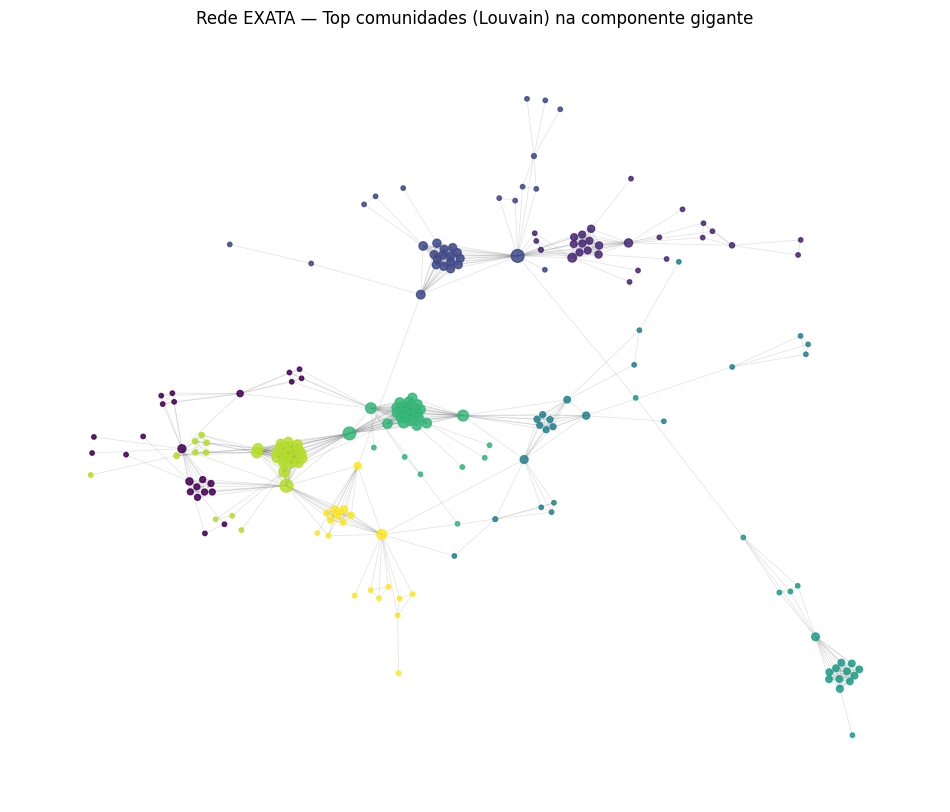

In [22]:
# =========================
# CÉLULA 4 — Comunidades (Louvain) + visualização por comunidade
# =========================
# pip install python-louvain (se necessário)
try:
    import community as community_louvain
except ImportError:
    raise ImportError("Instale com: pip install python-louvain")

partition = community_louvain.best_partition(G_gc, weight="weight", random_state=42)
mod = community_louvain.modularity(partition, G_gc, weight="weight")
print("Modularidade:", mod)

# Seleciona as maiores comunidades (para ficar legível)
from collections import Counter
comm_sizes = Counter(partition.values())
top_comms = [c for c, _ in comm_sizes.most_common(8)]
H = G_gc.subgraph([n for n in G_gc.nodes() if partition.get(n) in top_comms]).copy()

print("Subgrafo das top comunidades:", H.number_of_nodes(), "nós;", H.number_of_edges(), "arestas")

pos = nx.spring_layout(H, seed=42)

# cria lista de "cores" = id da comunidade (matplotlib mapeia automaticamente)
node_colors = [partition.get(n, -1) for n in H.nodes()]
node_sizes = [max(10, (G_gc.degree(n, weight="weight") * 2)) for n in H.nodes()]

plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(H, pos, node_size=node_sizes, node_color=node_colors, alpha=0.85)
nx.draw_networkx_edges(H, pos, alpha=0.10, width=0.6)
plt.title("Rede EXATA — Top comunidades (Louvain) na componente gigante")
plt.axis("off")
plt.show()

Top 10 betweenness:
9c997e9ea8924db522e5a9755b9e32cf 0.4591014358499305
36de514702d7b11e580390df7fbf4fc0 0.4359106582265454
c099801082b8658998f3d2993a99bdda 0.418324185249846
c052c859b42c5a1923c22f5a201de746 0.415899127805102
7bee5d31fc98596f51560e3cdbfe96ec 0.19589657816151576
dba6ec4290dad880a0a1faeae0c1386b 0.12493438320209974
cca8daddc1d026d14c4619182892efe8 0.11808054536169403
398b1df6658878cbbcde3f5a880b0123 0.1180793577273429
56b8359fd127312651b80b8ed8030085 0.10945084738739234
d7e837ad8409673341f42da837be915d 0.0926881878178775


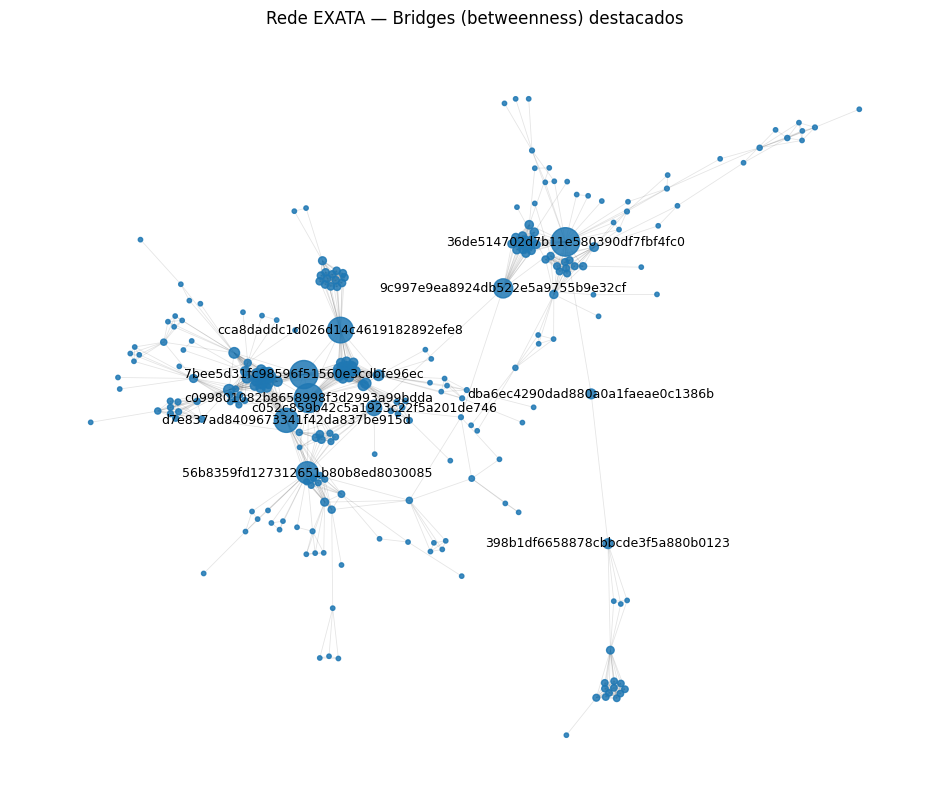

In [23]:
# =========================
# CÉLULA 5 — Top bridges (betweenness) e visualização destacando bridges
# =========================
# betweenness é pesado; vamos calcular só no G_gc e, se estiver grande, em k-core.
H = G_gc
if H.number_of_nodes() > 2000:
    H = nx.k_core(G_gc, k=3)
    print("GC grande: betweenness no k-core (k=3). nós:", H.number_of_nodes())

bet = nx.betweenness_centrality(H, weight="weight", normalized=True)
top_bet = sorted(bet.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 betweenness:")
for u, v in top_bet:
    print(u, v)

pos = nx.spring_layout(H, seed=42)
node_sizes = []
for n in H.nodes():
    # escala: grau ponderado + boost se for top bridge
    base_size = max(10, H.degree(n, weight="weight") * 2)
    if n in dict(top_bet):
        base_size *= 5
    node_sizes.append(base_size)

plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(H, pos, node_size=node_sizes, alpha=0.85)
nx.draw_networkx_edges(H, pos, alpha=0.10, width=0.6)

# labels só para top bridges (para não poluir)
labels = {u: u for u, _ in top_bet}
nx.draw_networkx_labels(H, pos, labels=labels, font_size=9)

plt.title("Rede EXATA — Bridges (betweenness) destacados")
plt.axis("off")
plt.show()

In [24]:
# =========================
# CÉLULA — Criar 'net' (PyVis) a partir de um subgrafo leve
# =========================
import networkx as nx
from pyvis.network import Network

# Use a componente gigante (melhor) se existir; senão use G
H = G_gc if "G_gc" in globals() else G

# Reduz para não ficar pesado (ajuste k se quiser)
if H.number_of_nodes() > 1500:
    H = nx.k_core(H, k=3)

net = Network(height="700px", width="100%", notebook=True, cdn_resources="in_line")
net.barnes_hut()

# Adiciona nós com tamanho proporcional ao grau
for n in H.nodes():
    # grau ponderado se existir
    try:
        size = max(5, H.degree(n, weight="weight"))
    except:
        size = max(5, H.degree(n))
    net.add_node(str(n), label=str(n), size=size)

# Adiciona arestas com peso
for u, v, data in H.edges(data=True):
    w = data.get("weight", 1)
    net.add_edge(str(u), str(v), value=w)

print("✅ net criado com", H.number_of_nodes(), "nós e", H.number_of_edges(), "arestas")

✅ net criado com 256 nós e 1268 arestas


In [25]:
# =========================
# CÉLULA 1 — Garantir GC e filtrar mensagens dos usuários da GC
# =========================
import networkx as nx
import pandas as pd

components = sorted(nx.connected_components(G), key=len, reverse=True)
gc_users = set(components[0]) if components else set()

lgb_df["is_gc_user"] = lgb_df["user_id"].astype(str).isin(gc_users)
lgb_gc = lgb_df[lgb_df["is_gc_user"]].copy()

print("GC usuários:", len(gc_users))
print("Mensagens na GC:", len(lgb_gc))
print("Hashes únicos na GC:", lgb_gc["msg_hash"].nunique())

GC usuários: 256
Mensagens na GC: 845
Hashes únicos na GC: 235


In [26]:
# =========================
# CÉLULA 2 — Top msg_hash por frequência dentro da GC + métricas de difusão
# =========================
top_hash_stats = (
    lgb_gc.groupby("msg_hash")
    .agg(
        freq_in_gc=("msg_hash", "size"),
        n_users=("user_id", lambda x: x.astype(str).nunique()),
        n_groups=("group_id", lambda x: x.astype(str).nunique() if "group_id" in lgb_gc.columns else 0),
        platforms=("platform", lambda x: ",".join(sorted(set(x.astype(str))))),
        datasets=("dataset_name", lambda x: ",".join(sorted(set(x.astype(str))))),
    )
    .reset_index()
    .sort_values("freq_in_gc", ascending=False)
)

top_hash_stats.head(10)

,msg_hash,freq_in_gc,n_users,n_groups,platforms,datasets
49,31cded0cd61f48499d800c5a4c72f7af7cc8ab30,27,10,6,"telegram,whatsapp","dataset_zap_2,telegram_dataset_02"
118,747fadbd48fdd719866903b9c6438ff68ee1bc64,25,10,8,"telegram,whatsapp","dataset_zap_1,telegram_dataset_01"
34,23a4745c17605d0b435d33e74b298974860b3bc5,25,21,18,"telegram,whatsapp","dataset_zap_2,telegram_dataset_02"
220,f4cebeeb65fde0d11392616aa46e293cffd28e33,22,22,17,whatsapp,dataset_zap_2
85,51915fc509a61e4af6519304cd3a25500a38d4b7,21,10,8,"telegram,whatsapp","dataset_zap_2,telegram_dataset_02"
163,a396653a1efc0aaf72c564d5ed830218ccab5884,20,17,16,whatsapp,dataset_zap_2
45,2de7690907a3e4f2b15d246c37ffc0e9020d634d,16,13,9,"telegram,whatsapp","dataset_zap_2,telegram_dataset_02"
58,3c0535b44dbf89bad3e187b7ea9f402f53010569,16,15,14,"telegram,whatsapp","dataset_zap_2,telegram_dataset_02"
5,075b6ba2364e42435f805cc30f70b63c8f6b4f44,14,10,9,"telegram,whatsapp","dataset_zap_2,telegram_dataset_02"
180,bec8e45dd5ef323cae505d0b42bc326bd703513b,14,3,5,telegram,telegram_dataset_01


In [27]:
# =========================
# CÉLULA 3 — Para cada msg_hash, pegar o texto literal "representativo" (mais frequente)
# =========================
def representative_text(dfh: pd.DataFrame) -> str:
    # escolhe o text_raw mais frequente dentro daquele hash
    vc = dfh["text_raw"].value_counts()
    return vc.index[0] if len(vc) else ""

topN = 10  # ajuste se quiser mais
top_hashes = top_hash_stats.head(topN)["msg_hash"].tolist()

rows = []
for h in top_hashes:
    dfh = lgb_gc[lgb_gc["msg_hash"] == h]
    rep_text = representative_text(dfh)

    rows.append({
        "msg_hash": h,
        "freq_in_gc": int(top_hash_stats.loc[top_hash_stats["msg_hash"] == h, "freq_in_gc"].iloc[0]),
        "n_users": int(top_hash_stats.loc[top_hash_stats["msg_hash"] == h, "n_users"].iloc[0]),
        "n_groups": int(top_hash_stats.loc[top_hash_stats["msg_hash"] == h, "n_groups"].iloc[0]),
        "platforms": top_hash_stats.loc[top_hash_stats["msg_hash"] == h, "platforms"].iloc[0],
        "datasets": top_hash_stats.loc[top_hash_stats["msg_hash"] == h, "datasets"].iloc[0],
        "text_literal": rep_text,
    })

top_offenses_literal = pd.DataFrame(rows).sort_values("freq_in_gc", ascending=False)
top_offenses_literal

,msg_hash,freq_in_gc,n_users,n_groups,platforms,datasets,text_literal
0,31cded0cd61f48499d800c5a4c72f7af7cc8ab30,27,10,6,"telegram,whatsapp","dataset_zap_2,telegram_dataset_02",COMPARTILHE TODOS OS DIAS AS AÇÕES DE NOSSO GOVERNO PARA RESTABELECIMENTO DA VERDADE (B)\n\n1- +1000 Obras de Infra ...
1,747fadbd48fdd719866903b9c6438ff68ee1bc64,25,10,8,"telegram,whatsapp","dataset_zap_1,telegram_dataset_01","A censura começa com um estranho, depois seu vizinho e logo chega em você!\nNão fique em cima do muro…\nO PT é um câ..."
2,23a4745c17605d0b435d33e74b298974860b3bc5,25,21,18,"telegram,whatsapp","dataset_zap_2,telegram_dataset_02","O filme ""Corpus Christi"" do diretor safado chámado deputado Jean Willys, aquele mesmo que ganhou o Big Brother, está..."
3,f4cebeeb65fde0d11392616aa46e293cffd28e33,22,22,17,whatsapp,dataset_zap_2,"*MINISTRO DA JUSTIÇA, (Flávio Dino)* Termina de apresentar proposta de (Decreto)\nQUE: A PARTIR DE 23/03/2023 , SERÁ..."
4,51915fc509a61e4af6519304cd3a25500a38d4b7,21,10,8,"telegram,whatsapp","dataset_zap_2,telegram_dataset_02","""Boa tarde, Ana, estou lhe acompanhando no seu grupo, vou me apresentar sou policial civil do estado de são Paulo, t..."
5,a396653a1efc0aaf72c564d5ed830218ccab5884,20,17,16,whatsapp,dataset_zap_2,*Assista pelo menos os primeiros 20 minutos.*\n\n*ANOMALIAS QUE COMPROVAM FRAUDES NAS ELEIÇÕES*\n\n*1°* Um mesário a...
6,2de7690907a3e4f2b15d246c37ffc0e9020d634d,16,13,9,"telegram,whatsapp","dataset_zap_2,telegram_dataset_02","Juiz abre seleção para estagiários trans, gays e lésbicas e proíbe héteros: “Não haverá contratação, em nenhuma hipó..."
7,3c0535b44dbf89bad3e187b7ea9f402f53010569,16,15,14,"telegram,whatsapp","dataset_zap_2,telegram_dataset_02","Brasil em oração 👼😇\n\nTire 30 seg e ore com fé pelo Brasil. Leia abaixo e passe adiante. 🙏🌎🙏\n\n*Amado Jesus, Poder..."
8,075b6ba2364e42435f805cc30f70b63c8f6b4f44,14,10,9,"telegram,whatsapp","dataset_zap_2,telegram_dataset_02","*MINISTRO DA JUSTIÇA, (NEM CITAREI O NOME)* termina de apresentar proposta de (Decreto)\nQUE: A PARTIR DE 23/03/2023..."
9,bec8e45dd5ef323cae505d0b42bc326bd703513b,14,3,5,telegram,telegram_dataset_01,COMPARTILHE A VERDADE!\nFeitos e planos de Inácio Larápiosauro\nVeja seus planos macabros de governar o Brasil \n# I...


In [28]:
# =========================
# CÉLULA 4 — (Opcional) Exportar para CSV (CUIDADO: contém ofensa literal)
# =========================
out_csv = r"top_offenses_literal_gc.csv"
top_offenses_literal.to_csv(out_csv, index=False, encoding="utf-8-sig")
print("⚠️ CSV com conteúdo ofensivo salvo em:", out_csv)

⚠️ CSV com conteúdo ofensivo salvo em: top_offenses_literal_gc.csv


In [29]:
print("terms_found existe?", "terms_found" in lgb_df.columns)
if "terms_found" in lgb_df.columns:
    print(lgb_df["terms_found"].head(5))
    print("Proporção term_count>0:", (lgb_df.get("term_count", 0) > 0).mean())

terms_found existe? False


In [30]:
import re
import pandas as pd

# Certifique-se de ter lgb_terms e text_norm_basic
assert "lgb_terms" in globals(), "lgb_terms não existe no seu notebook ainda"
assert "text_norm_basic" in lgb_df.columns, "text_norm_basic não está em lgb_df"

def term_to_regex(term: str) -> str:
    if term.endswith("*"):
        prefix = re.escape(term[:-1])
        return rf"\b{prefix}\w*\b"
    return rf"\b{re.escape(term)}\b"

# compila regex por termo (sim, é mais caro, mas em 3491 linhas dá)
compiled = [(t, re.compile(term_to_regex(t), flags=re.IGNORECASE)) for t in lgb_terms]

def matched_terms(text):
    hits = []
    for t, rx in compiled:
        if rx.search(text):
            hits.append(t)
    return hits

# Isso pode demorar um pouco, mas é o diagnóstico definitivo
lgb_df["terms_found_diag"] = lgb_df["text_norm_basic"].apply(matched_terms)
lgb_df["term_count_diag"] = lgb_df["terms_found_diag"].apply(len)

print("Mensagens com >=1 termo encontrado:", (lgb_df["term_count_diag"] > 0).sum(), "de", len(lgb_df))

# Top termos disparadores
from collections import Counter
c = Counter()
for lst in lgb_df["terms_found_diag"]:
    for t in lst:
        c[t] += 1

pd.DataFrame(c.most_common(30), columns=["term", "freq_trigger"]).head(30)

Mensagens com >=1 termo encontrado: 4376 de 4376


,term,freq_trigger
0,ativismo,1032
1,ativo*,684
2,cura,616
3,gay,535
4,viad*,417
5,ativo,335
6,gays,304
7,imoral*,304
8,viado,258
9,imoral,203


In [31]:
import random

# pega 10 exemplos aleatórios com termo encontrado
ex = lgb_df[lgb_df["term_count_diag"] > 0].sample(10, random_state=42)

for i, r in ex.iterrows():
    print("\n---")
    print("terms_found_diag:", r["terms_found_diag"][:10])
    print("RAW:", r["text_raw"][:300])


---
terms_found_diag: ['cura']
RAW: 🌏👁🤖 Fórum Econômico Mundial declara que 'os humanos são uma praga' e 'IA é a cura'

Yuval Noah Harari, principal consultor de Klaus Schwab no Fórum Econômico Mundial, anunciou que os seres humanos não são melhores do que “vírus ou bananas” e o WEF agora chegou ao ponto em que eles podem “hackear a h

---
terms_found_diag: ['todes']
RAW: Governo Lula vai ter Ministério de Todes - 09/11/2022 - Flavia Boggio - Folha
https://www1.folha.uol.com.br/colunas/flavia-boggio/2022/11/governo-lula-vai-ter-ministerio-de-todes-no-lugar-do-da-mulher.shtml

---
terms_found_diag: ['cura']
RAW: Senhor Jesus... Pai de toda ciência e sabedoria, tenha Misericórdia do Teu filho *Jair Messias Bolsonaro* dirigente eleito conforme Tua vontade para governar a Nação Brasileira. Tenha misericórdia do Teu povo sofrido e esperançoso , perdoe nossas iniquidades, pecados que muitas vezes feriu Teu coraç

---
terms_found_diag: ['ativo', 'ativo*']
RAW: O ponto que já está ativo é em 

In [32]:
# Mostra categorias que contêm "lgb" no nome
hits = [(cid, name) for cid, name in categories.items() if "lgb" in name.lower()]
hits[:30], len(hits)

([(4, 'LGBTFobia')], 1)

In [33]:
import re
from collections import Counter

def term_to_regex(term: str) -> str:
    if term.endswith("*"):
        prefix = re.escape(term[:-1])
        return rf"\b{prefix}\w*\b"
    return rf"\b{re.escape(term)}\b"

compiled = [(t, re.compile(term_to_regex(t), flags=re.IGNORECASE)) for t in lgb_terms]

def matched_terms(text):
    hits = []
    for t, rx in compiled:
        if rx.search(text):
            hits.append(t)
    return hits

# ⚠️ isso roda rápido com 3491 linhas
lgb_df["terms_found_diag"] = lgb_df["text_norm_basic"].apply(matched_terms)

# Contar quais termos disparam mais
c = Counter()
for lst in lgb_df["terms_found_diag"]:
    for t in lst:
        c[t] += 1

top_terms = pd.DataFrame(c.most_common(50), columns=["term", "freq_trigger"])
top_terms.head(30)

,term,freq_trigger
0,ativismo,1032
1,ativo*,684
2,cura,616
3,gay,535
4,viad*,417
5,ativo,335
6,gays,304
7,imoral*,304
8,viado,258
9,imoral,203


In [34]:
# =========================
# CÉLULA 1 — Garantir lgb_df, lgb_terms, text_norm_basic
# =========================
assert "lgb_df" in globals(), "lgb_df não existe"
assert "lgb_terms" in globals(), "lgb_terms não existe"
assert "text_norm_basic" in lgb_df.columns, "text_norm_basic não está em lgb_df"
print("OK. lgb_df:", lgb_df.shape)

OK. lgb_df: (4376, 14)


In [35]:
# =========================
# CÉLULA 2 — Persistir terms_found / term_count (diagnóstico definitivo)
# =========================
import re

def term_to_regex(term: str) -> str:
    if term.endswith("*"):
        prefix = re.escape(term[:-1])
        return rf"\b{prefix}\w*\b"
    return rf"\b{re.escape(term)}\b"

compiled = [(t, re.compile(term_to_regex(t), flags=re.IGNORECASE)) for t in lgb_terms]

def matched_terms(text: str):
    hits = []
    for t, rx in compiled:
        if rx.search(text):
            hits.append(t)
    return hits

lgb_df["terms_found"] = lgb_df["text_norm_basic"].astype(str).apply(matched_terms)
lgb_df["term_count"] = lgb_df["terms_found"].apply(len)

print(lgb_df["term_count"].describe())
lgb_df[["text_raw", "terms_found", "term_count"]].sample(5, random_state=42)

count    4376.000000
mean        1.382084
std         0.671230
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: term_count, dtype: float64


,text_raw,terms_found,term_count
1429273,"🌏👁🤖 Fórum Econômico Mundial declara que 'os humanos são uma praga' e 'IA é a cura'\n\nYuval Noah Harari, principal c...",[cura],1
1042032,Governo Lula vai ter Ministério de Todes - 09/11/2022 - Flavia Boggio - Folha\nhttps://www1.folha.uol.com.br/colunas...,[todes],1
234117,"Senhor Jesus... Pai de toda ciência e sabedoria, tenha Misericórdia do Teu filho *Jair Messias Bolsonaro* dirigente ...",[cura],1
165891,O ponto que já está ativo é em frente ao segundo Bis mas quem quiser ir para o quartel general pode ir o que não pod...,"[ativo, ativo*]",2
702667,"Ser viado agora é problema, rs\nEssa esquerda é patética, sem noção.\nE o garoto nem é, o que é o pior.\nhttps://t.m...","[viad*, viado]",2


In [36]:
# =========================
# CÉLULA 3 — Marcar núcleo (GC) e separar GC vs fora do GC
# =========================
import networkx as nx

assert "G" in globals(), "G (grafo usuário-usuário) não existe"

components = sorted(nx.connected_components(G), key=len, reverse=True)
gc_users = set(components[0]) if components else set()

lgb_df["is_gc_user"] = lgb_df["user_id"].astype(str).isin(gc_users)

lgb_gc = lgb_df[lgb_df["is_gc_user"]].copy()
lgb_out = lgb_df[~lgb_df["is_gc_user"]].copy()

print("GC users:", len(gc_users))
print("Msgs GC:", len(lgb_gc), "| Msgs fora GC:", len(lgb_out))
print("Users GC:", lgb_gc["user_id"].nunique(), "| Users fora GC:", lgb_out["user_id"].nunique())

GC users: 256
Msgs GC: 845 | Msgs fora GC: 3531
Users GC: 256 | Users fora GC: 1384


In [37]:
# =========================
# CÉLULA 4 — Perfil lexical: top termos no núcleo vs fora do núcleo
# =========================
from collections import Counter
import pandas as pd

def term_freq(df: pd.DataFrame, col="terms_found") -> Counter:
    c = Counter()
    for lst in df[col]:
        for t in lst:
            c[t] += 1
    return c

c_gc = term_freq(lgb_gc)
c_out = term_freq(lgb_out)

top_gc = pd.DataFrame(c_gc.most_common(30), columns=["term", "freq_gc"])
top_out = pd.DataFrame(c_out.most_common(30), columns=["term", "freq_out"])

print("Top termos na GC:")
display(top_gc.head(20))

print("\nTop termos fora da GC:")
display(top_out.head(20))

Top termos na GC:


,term,freq_gc
0,ativismo,312
1,ativo*,200
2,gay,106
3,gays,93
4,cura,88
5,ativo,60
6,viad*,59
7,imoral*,49
8,imoral,44
9,viado,39



Top termos fora da GC:


,term,freq_out
0,ativismo,720
1,cura,528
2,ativo*,484
3,gay,429
4,viad*,358
5,ativo,275
6,imoral*,255
7,viado,219
8,gays,211
9,todes,184


In [38]:
# =========================
# CÉLULA 5 — Comparação normalizada (taxa por 1000 msgs) e "enriquecimento" no núcleo
# =========================
N_gc = len(lgb_gc)
N_out = len(lgb_out)

all_terms = sorted(set(c_gc.keys()).union(set(c_out.keys())))

rows = []
for t in all_terms:
    f_gc = c_gc.get(t, 0)
    f_out = c_out.get(t, 0)
    rate_gc = (f_gc / N_gc) * 1000 if N_gc else 0
    rate_out = (f_out / N_out) * 1000 if N_out else 0
    enrichment = (rate_gc / rate_out) if rate_out > 0 else (float("inf") if rate_gc > 0 else 0)
    rows.append((t, f_gc, f_out, rate_gc, rate_out, enrichment))

lex_profile = pd.DataFrame(rows, columns=["term","freq_gc","freq_out","rate_gc_per_1k","rate_out_per_1k","enrichment_gc_vs_out"])
lex_profile = lex_profile.sort_values(["enrichment_gc_vs_out","freq_gc"], ascending=[False, False])

# remove 'inf' pro display se quiser
lex_profile.head(30)

,term,freq_gc,freq_out,rate_gc_per_1k,rate_out_per_1k,enrichment_gc_vs_out
9,bichas,10,9,11.834320,2.548853,4.642998
11,bichona,15,26,17.751479,7.363353,2.410787
24,gays,93,211,110.059172,59.756443,1.841796
3,ativismo,312,720,369.230769,203.908241,1.810769
21,fresca,6,14,7.100592,3.964882,1.790871
5,ativo*,200,484,236.686391,137.071651,1.726735
19,encubado,2,5,2.366864,1.416029,1.671479
25,homossexualismo,5,14,5.917160,3.964882,1.492392
41,traveco,9,27,10.650888,7.646559,1.392899
26,imoral,44,159,52.071006,45.029737,1.156369


In [39]:
# =========================
# CÉLULA 6 — Definir grupos: ambíguos vs pejorativos (ajuste a lista como quiser)
# =========================
ambiguous = {
    "ativo*", "ativo",
    "passivo*", "passivo",
    "puto", "putos", "putinha",
    "gay", "gays",
    "todes"
}

# tudo que não está em ambiguous será tratado como "pejorativo/diretamente estigmatizante" (baseline)
# Você pode também montar uma lista pejorativa explícita se preferir.

def has_any_term(lst, termset):
    return any(t in termset for t in lst)

lgb_df["has_ambiguous"] = lgb_df["terms_found"].apply(lambda lst: has_any_term(lst, ambiguous))
lgb_df["has_pejorative"] = lgb_df["terms_found"].apply(lambda lst: any(t not in ambiguous for t in lst))

# taxas GC vs fora
summary = pd.DataFrame({
    "subset": ["GC", "Fora GC"],
    "n_msgs": [len(lgb_gc), len(lgb_out)],
    "pct_has_ambiguous": [
        lgb_gc["terms_found"].apply(lambda lst: has_any_term(lst, ambiguous)).mean(),
        lgb_out["terms_found"].apply(lambda lst: has_any_term(lst, ambiguous)).mean()
    ],
    "pct_has_pejorative": [
        lgb_gc["terms_found"].apply(lambda lst: any(t not in ambiguous for t in lst)).mean(),
        lgb_out["terms_found"].apply(lambda lst: any(t not in ambiguous for t in lst)).mean()
    ],
})

summary

,subset,n_msgs,pct_has_ambiguous,pct_has_pejorative
0,GC,845,0.519527,0.486391
1,Fora GC,3531,0.453696,0.556500


In [40]:
# =========================
# CÉLULA 7 — Top termos "pejorativos" na GC (excluindo ambíguos)
# =========================
c_gc_pej = Counter()
for lst in lgb_gc["terms_found"]:
    for t in lst:
        if t not in ambiguous:
            c_gc_pej[t] += 1

pd.DataFrame(c_gc_pej.most_common(30), columns=["term_pejorative", "freq_in_gc"]).head(30)

,term_pejorative,freq_in_gc
0,ativismo,312
1,cura,88
2,viad*,59
3,imoral*,49
4,imoral,44
5,viado,39
6,anormal,21
7,travesti,16
8,bichona,15
9,bichas,10


In [41]:
from collections import Counter

ambiguous = {"ativo*", "ativo", "passivo*", "passivo", "gay", "gays", "todes", "puto", "putos", "putinha"}

def has_any(lst, S): 
    return any(t in S for t in lst)

lgb_gc["has_ambiguous"] = lgb_gc["terms_found"].apply(lambda lst: has_any(lst, ambiguous))
lgb_out["has_ambiguous"] = lgb_out["terms_found"].apply(lambda lst: has_any(lst, ambiguous))

lgb_gc["has_pejorative"] = lgb_gc["terms_found"].apply(lambda lst: any(t not in ambiguous for t in lst))
lgb_out["has_pejorative"] = lgb_out["terms_found"].apply(lambda lst: any(t not in ambiguous for t in lst))

summary = pd.DataFrame({
    "subset": ["GC", "Fora GC"],
    "n_msgs": [len(lgb_gc), len(lgb_out)],
    "pct_has_ambiguous": [lgb_gc["has_ambiguous"].mean(), lgb_out["has_ambiguous"].mean()],
    "pct_has_pejorative": [lgb_gc["has_pejorative"].mean(), lgb_out["has_pejorative"].mean()],
})
summary

,subset,n_msgs,pct_has_ambiguous,pct_has_pejorative
0,GC,845,0.519527,0.486391
1,Fora GC,3531,0.453696,0.556500


In [42]:
from collections import Counter

c_pej_gc = Counter()
for lst in lgb_gc["terms_found"]:
    for t in lst:
        if t not in ambiguous:
            c_pej_gc[t] += 1

pd.DataFrame(c_pej_gc.most_common(20), columns=["term_pejorative", "freq_in_gc"])

,term_pejorative,freq_in_gc
0,ativismo,312
1,cura,88
2,viad*,59
3,imoral*,49
4,imoral,44
5,viado,39
6,anormal,21
7,travesti,16
8,bichona,15
9,bichas,10


In [43]:
# GC dividido em 2 grupos: pejorativo vs apenas ambíguo
gc = lgb_df[lgb_df["is_gc_user"]].copy()

gc_amb_only = gc[(gc["has_ambiguous"]) & (~gc["has_pejorative"])].copy()
gc_pej = gc[gc["has_pejorative"]].copy()

print("GC total:", len(gc))
print("GC ambíguo apenas:", len(gc_amb_only))
print("GC com pejorativo:", len(gc_pej))

# Top termos no GC ambíguo-apenas
from collections import Counter
c = Counter()
for lst in gc_amb_only["terms_found"]:
    for t in lst:
        c[t] += 1
pd.DataFrame(c.most_common(20), columns=["term", "freq"]).head(20)

GC total: 845
GC ambíguo apenas: 434
GC com pejorativo: 411


,term,freq
0,ativo*,196
1,gay,105
2,gays,92
3,ativo,56
4,passivo*,25
5,puto,18
6,todes,6


In [44]:
# =========================
# CÉLULA 1 — Construir mapeamento msg_hash -> content_id (sequencial, human-readable)
# =========================
import pandas as pd

# lgb_gc precisa existir (mensagens de usuários na GC)
assert "lgb_gc" in globals(), "lgb_gc não existe ainda"
assert "msg_hash" in lgb_gc.columns, "msg_hash não existe em lgb_gc"

# pega hashes ordenados por frequência (os mais importantes recebem IDs menores)
hash_rank = lgb_gc["msg_hash"].value_counts().reset_index()
hash_rank.columns = ["msg_hash", "freq_in_gc"]
hash_rank["content_id"] = range(1, len(hash_rank) + 1)

# dicionário pra mapear rápido
hash_to_content_id = dict(zip(hash_rank["msg_hash"], hash_rank["content_id"]))

# adiciona content_id ao dataframe GC
lgb_gc["content_id"] = lgb_gc["msg_hash"].map(hash_to_content_id)

hash_rank.head(10)

,msg_hash,freq_in_gc,content_id
0,31cded0cd61f48499d800c5a4c72f7af7cc8ab30,27,1
1,23a4745c17605d0b435d33e74b298974860b3bc5,25,2
2,747fadbd48fdd719866903b9c6438ff68ee1bc64,25,3
3,f4cebeeb65fde0d11392616aa46e293cffd28e33,22,4
4,51915fc509a61e4af6519304cd3a25500a38d4b7,21,5
5,a396653a1efc0aaf72c564d5ed830218ccab5884,20,6
6,2de7690907a3e4f2b15d246c37ffc0e9020d634d,16,7
7,3c0535b44dbf89bad3e187b7ea9f402f53010569,16,8
8,075b6ba2364e42435f805cc30f70b63c8f6b4f44,14,9
9,bec8e45dd5ef323cae505d0b42bc326bd703513b,14,10


In [45]:
# =========================
# CÉLULA 2 — Estatísticas por content_id (freq, usuários, plataformas)
# =========================
content_stats = (
    lgb_gc.groupby("content_id")
    .agg(
        freq_in_gc=("content_id", "size"),
        n_users=("user_id", lambda x: x.astype(str).nunique()),
        n_groups=("group_id", lambda x: x.astype(str).nunique() if "group_id" in lgb_gc.columns else 0),
        platforms=("platform", lambda x: ",".join(sorted(set(x.astype(str))))),
        msg_hash=("msg_hash", "first"),
    )
    .reset_index()
    .sort_values("freq_in_gc", ascending=False)
)

content_stats.head(10)

,content_id,freq_in_gc,n_users,n_groups,platforms,msg_hash
0,1,27,10,6,"telegram,whatsapp",31cded0cd61f48499d800c5a4c72f7af7cc8ab30
2,3,25,10,8,"telegram,whatsapp",747fadbd48fdd719866903b9c6438ff68ee1bc64
1,2,25,21,18,"telegram,whatsapp",23a4745c17605d0b435d33e74b298974860b3bc5
3,4,22,22,17,whatsapp,f4cebeeb65fde0d11392616aa46e293cffd28e33
4,5,21,10,8,"telegram,whatsapp",51915fc509a61e4af6519304cd3a25500a38d4b7
5,6,20,17,16,whatsapp,a396653a1efc0aaf72c564d5ed830218ccab5884
6,7,16,13,9,"telegram,whatsapp",2de7690907a3e4f2b15d246c37ffc0e9020d634d
7,8,16,15,14,"telegram,whatsapp",3c0535b44dbf89bad3e187b7ea9f402f53010569
8,9,14,10,9,"telegram,whatsapp",075b6ba2364e42435f805cc30f70b63c8f6b4f44
9,10,14,3,5,telegram,bec8e45dd5ef323cae505d0b42bc326bd703513b


In [46]:
# =========================
# CÉLULA 3 — Escolher texto literal representativo (com mais termos) por content_id
# =========================
def best_example(df: pd.DataFrame) -> pd.Series:
    # garante term_count (se não existir, cria rápido)
    if "term_count" not in df.columns:
        df = df.copy()
        df["term_count"] = df["terms_found"].apply(len) if "terms_found" in df.columns else 0

    df = df.copy()
    df["raw_len"] = df["text_raw"].astype(str).str.len()
    df = df.sort_values(["term_count", "raw_len"], ascending=[False, False])
    return df.iloc[0]

# Top N conteúdos para você ler (ajuste)
TOPN = 20

rows = []
for cid in content_stats.head(TOPN)["content_id"].tolist():
    dfc = lgb_gc[lgb_gc["content_id"] == cid]
    ex = best_example(dfc)

    st = content_stats[content_stats["content_id"] == cid].iloc[0]
    rows.append({
        "content_id": int(cid),
        "freq_in_gc": int(st["freq_in_gc"]),
        "n_users": int(st["n_users"]),
        "n_groups": int(st["n_groups"]),
        "platforms": st["platforms"],
        "terms_found_example": ex.get("terms_found", []),
        "text_literal": ex["text_raw"],
    })

top_contents_readable = pd.DataFrame(rows).sort_values("freq_in_gc", ascending=False)
top_contents_readable

,content_id,freq_in_gc,n_users,n_groups,platforms,terms_found_example,text_literal
0,1,27,10,6,"telegram,whatsapp","[ativo, ativo*]",COMPARTILHE TODOS OS DIAS AS AÇÕES DE NOSSO GOVERNO PARA RESTABELECIMENTO DA VERDADE (B)\n\n1- +1000 Obras de Infra ...
2,2,25,21,18,"telegram,whatsapp",[gays],"O filme ""Corpus Christi"" do diretor safado chámado deputado Jean Willys, aquele mesmo que ganhou o Big Brother, está..."
1,3,25,10,8,"telegram,whatsapp",[cura],"A censura começa com um estranho, depois seu vizinho e logo chega em você!\n\nNão fique em cima do muro…\n\nO PT é u..."
3,4,22,22,17,whatsapp,[ativo*],"*MINISTRO DA JUSTIÇA, (Flávio Dino)* Termina de apresentar proposta de (Decreto)\nQUE: A PARTIR DE 23/03/2023 , SERÁ..."
4,5,21,10,8,"telegram,whatsapp",[ativo*],"""Boa tarde, Ana, estou lhe acompanhando no seu grupo, vou me apresentar sou policial civil do estado de são Paulo, t..."
5,6,20,17,16,whatsapp,[ativo*],*Assista pelo menos os primeiros 20 minutos.*\n\n*ANOMALIAS QUE COMPROVAM FRAUDES NAS ELEIÇÕES*\n\n*1°* Um mesário a...
6,7,16,13,9,"telegram,whatsapp",[gays],"Juiz abre seleção para estagiários trans, gays e lésbicas e proíbe héteros: “Não haverá contratação, em nenhuma hipó..."
7,8,16,15,14,"telegram,whatsapp",[cura],"Brasil em oração 👼😇\n\nTire 30 seg e ore com fé pelo Brasil. Leia abaixo e passe adiante. 🙏🌎🙏\n\n*Amado Jesus, Poder..."
8,9,14,10,9,"telegram,whatsapp",[ativo*],"*MINISTRO DA JUSTIÇA, (NEM CITAREI O NOME)* termina de apresentar proposta de (Decreto)\nQUE: A PARTIR DE 23/03/2023..."
9,10,14,3,5,telegram,[gay],COMPARTILHE A VERDADE!\nFeitos e planos de Inácio Larápiosauro\nVeja seus planos macabros de governar o Brasil \n# I...


In [47]:
# =========================
# CÉLULA 4 — Exportar CSV (para revisar / anexar material suplementar)
# =========================
out_csv = "top_contents_GC_human_readable.csv"
top_contents_readable.to_csv(out_csv, index=False, encoding="utf-8-sig")
print("✅ Salvo:", out_csv)

✅ Salvo: top_contents_GC_human_readable.csv


Mensagens com timestamp válido: 4376 / 4376
Sem timestamp (NaT): 0 — serão excluídas da análise temporal

Período coberto: 2022-08-19 → 2023-02-14
Semanas distintas: 27

Distribuição por plataforma (com timestamp):
plat_clean
telegram    2174
whatsapp    2070
unknown      132
Name: count, dtype: int64
Semanas com dados:
       semana  n_msgs  n_usuarios  n_hashes  n_gc
0  2022-08-15       5           5         5     0
1  2022-08-22      36          26        36     0
2  2022-08-29      60          46        49     7
3  2022-09-05      42          36        39     7
4  2022-09-12      58          39        30    15
5  2022-09-19     101          72        77    18
6  2022-09-26     207         111       113    33
7  2022-10-03     424         190       221    54
8  2022-10-10     294         127       158    43
9  2022-10-17     289         138       154    64
10 2022-10-24     340         158       160    88
11 2022-10-31     351         135       148    13
12 2022-11-07     104       

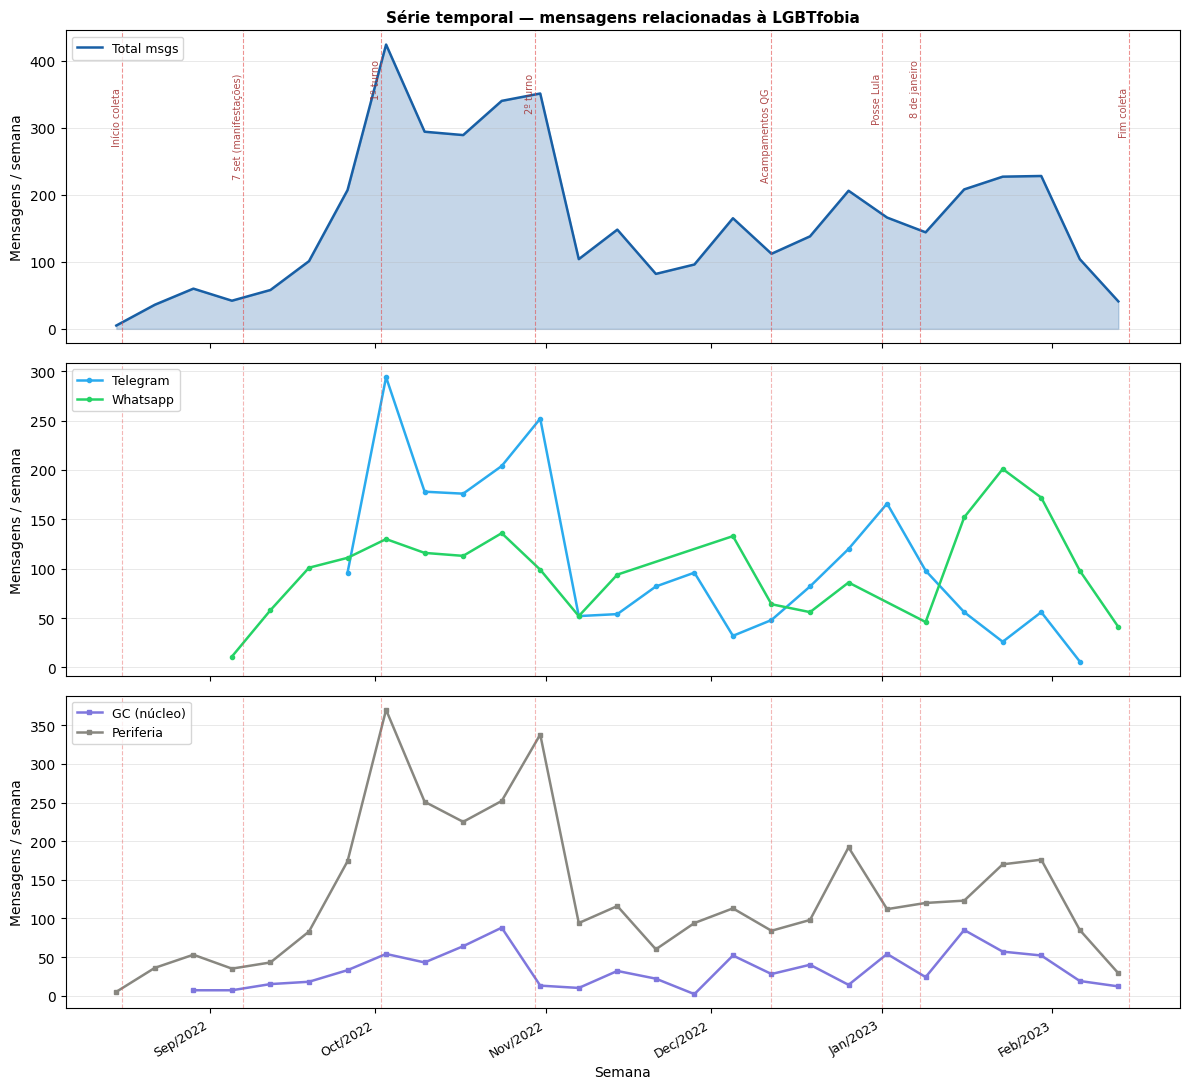

✅ Figura salva: fig_serie_temporal.pdf / .png


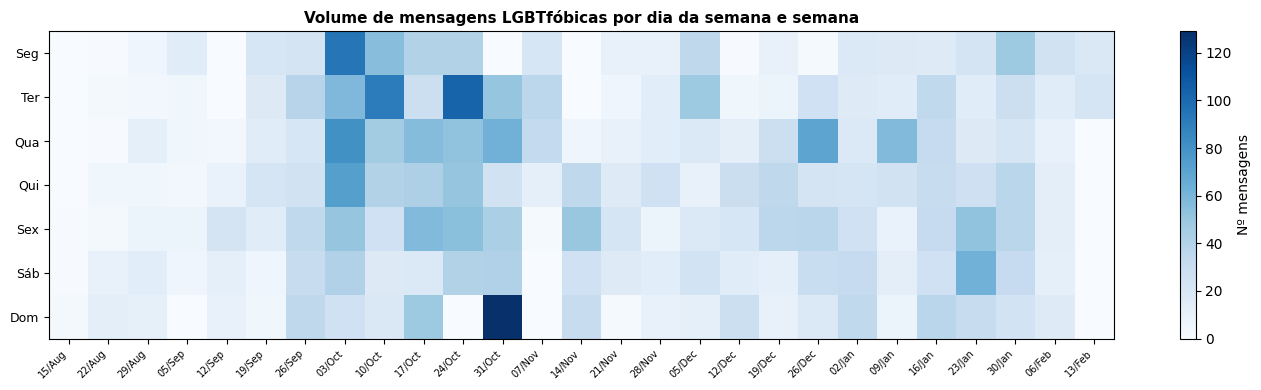

✅ Figura salva: fig_heatmap_temporal.pdf / .png

Semanas com pico (z > 1.5): 3
       semana  n_msgs  n_usuarios    z_msgs
7  2022-10-03     424         190  2.438919
10 2022-10-24     340         158  1.656754
11 2022-10-31     351         135  1.759180

Picos e eventos próximos:
       semana  n_msgs    z_msgs evento_proximo
7  2022-10-03     424  2.438919       1º turno
10 2022-10-24     340  1.656754       2º turno
11 2022-10-31     351  1.759180       2º turno

% ---- Tabela de picos temporais (cole na Secao 5) ----
\begin{table}[ht]
\centering
\caption{Semanas com volume anormal de mensagens LGBTf\'obicas ($z > 1{,}5$)
          e eventos pol\'iticos contempor\^aneos.}
\label{tab:picos}
\small
\begin{tabular}{lrrr}
\hline
\textbf{Semana} & \textbf{Msgs} & \textbf{$z$-score} &
\textbf{Evento pr\'oximo} \\
\hline
    03/10/2022 & 424 & 2.44 & 1º turno \\
    24/10/2022 & 340 & 1.66 & 2º turno \\
    31/10/2022 & 351 & 1.76 & 2º turno \\
\hline
\end{tabular}
\end{table}


  NÚMEROS 

In [51]:
"""
=============================================================
 MELHORIA 3 — ANÁLISE TEMPORAL DA DIFUSÃO LGBTFÓBICA
 Artigo SBBD 2026
=============================================================
 Cole este script em células do Untitled__3_.ipynb,
 APÓS as células que criam lgb_df (com terms_found e
 is_gc_user já definidos).

 Gera:
   - Série temporal semanal de volume de msgs LGBTfóbicas
   - Separado por plataforma (WA vs TG)
   - Separado por núcleo (GC) vs periferia
   - Linha do tempo de eventos políticos sobrepostos
   - Heatmap dia-da-semana × semana
   - Tabela LaTeX com eventos e picos
=============================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# CÉLULA A — Preparar lgb_df com timestamp limpo
# ============================================================

assert "lgb_df" in globals(), "lgb_df não existe"
assert "is_gc_user" in lgb_df.columns, "rode a célula de GC primeiro"

df = lgb_df.copy()

# converte timestamp, descarta NaT
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
n_sem_ts = df["timestamp"].isna().sum()
print(f"Mensagens com timestamp válido: {df['timestamp'].notna().sum()} / {len(df)}")
print(f"Sem timestamp (NaT): {n_sem_ts} — serão excluídas da análise temporal")

df_ts = df[df["timestamp"].notna()].copy()
df_ts["semana"]    = df_ts["timestamp"].dt.to_period("W").dt.start_time
df_ts["mes"]       = df_ts["timestamp"].dt.to_period("M").dt.start_time
df_ts["dia_semana"]= df_ts["timestamp"].dt.day_name()
df_ts["plat_clean"]= df_ts["platform"].replace({"nan": "unknown"}).str.lower()

print(f"\nPeríodo coberto: {df_ts['timestamp'].min().date()} → {df_ts['timestamp'].max().date()}")
print(f"Semanas distintas: {df_ts['semana'].nunique()}")
print("\nDistribuição por plataforma (com timestamp):")
print(df_ts["plat_clean"].value_counts())

# ============================================================
# CÉLULA B — Eventos políticos do período eleitoral BR-2022
# ============================================================
# Esses eventos são usados para contextualizar os picos na série temporal.
# Fonte: datas públicas verificáveis.

eventos = [
    # (data_str,           label_curto,                  y_pos)
    ("2022-08-16", "Início coleta",              0.85),
    ("2022-09-07", "7 set (manifestações)",      0.90),
    ("2022-10-02", "1º turno",                   0.95),
    ("2022-10-30", "2º turno",                   0.90),
    ("2022-12-12", "Acampamentos QG",            0.85),
    ("2023-01-01", "Posse Lula",                 0.90),
    ("2023-01-08", "8 de janeiro",               0.95),
    ("2023-02-15", "Fim coleta",                 0.85),
]
eventos_df = pd.DataFrame(eventos, columns=["data", "label", "y_norm"])
eventos_df["data"] = pd.to_datetime(eventos_df["data"])

# ============================================================
# CÉLULA C — Série semanal geral + por plataforma
# ============================================================

# --- volume semanal geral ---
semanal = (
    df_ts.groupby("semana")
    .agg(
        n_msgs=("msg_hash", "size"),
        n_usuarios=("user_id", "nunique"),
        n_hashes=("msg_hash", "nunique"),
        n_gc=("is_gc_user", "sum"),
    )
    .reset_index()
    .sort_values("semana")
)

# --- por plataforma ---
semanal_plat = (
    df_ts[df_ts["plat_clean"].isin(["whatsapp","telegram"])]
    .groupby(["semana","plat_clean"])
    .agg(n_msgs=("msg_hash","size"))
    .reset_index()
)

# --- GC vs periferia ---
semanal_gc = (
    df_ts.groupby(["semana","is_gc_user"])
    .agg(n_msgs=("msg_hash","size"))
    .reset_index()
)
semanal_gc["grupo"] = semanal_gc["is_gc_user"].map({True:"GC (núcleo)", False:"Periferia"})

print("Semanas com dados:")
print(semanal[["semana","n_msgs","n_usuarios","n_hashes","n_gc"]].to_string())

# ============================================================
# CÉLULA D — Figura 1: Série temporal geral com eventos
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
fig.subplots_adjust(hspace=0.08)

cores = {"whatsapp": "#25D366", "telegram": "#2AABEE",
         "GC (núcleo)": "#7F77DD", "Periferia": "#888780"}

# --- painel 1: volume total ---
ax1 = axes[0]
ax1.fill_between(semanal["semana"], semanal["n_msgs"],
                 alpha=0.25, color="#185FA5")
ax1.plot(semanal["semana"], semanal["n_msgs"],
         color="#185FA5", linewidth=1.8, label="Total msgs")
ax1.set_ylabel("Mensagens / semana", fontsize=10)
ax1.set_title("Série temporal — mensagens relacionadas à LGBTfobia",
              fontsize=11, fontweight="bold", pad=6)

# sobrepõe eventos
ymax1 = semanal["n_msgs"].max()
for _, ev in eventos_df.iterrows():
    ax1.axvline(ev["data"], color="#E24B4A", linewidth=0.8,
                linestyle="--", alpha=0.6)
    ax1.text(ev["data"], ymax1 * ev["y_norm"], ev["label"],
             fontsize=7, rotation=90, va="top", ha="right",
             color="#A32D2D", alpha=0.85)

ax1.legend(fontsize=9, loc="upper left")
ax1.grid(axis="y", linewidth=0.4, alpha=0.5)

# --- painel 2: por plataforma ---
ax2 = axes[1]
for plat, grp in semanal_plat.groupby("plat_clean"):
    ax2.plot(grp["semana"], grp["n_msgs"],
             color=cores.get(plat, "#888"), linewidth=1.8,
             label=plat.capitalize(), marker="o", markersize=3)

ymax2 = semanal_plat["n_msgs"].max()
for _, ev in eventos_df.iterrows():
    ax2.axvline(ev["data"], color="#E24B4A", linewidth=0.8,
                linestyle="--", alpha=0.4)

ax2.set_ylabel("Mensagens / semana", fontsize=10)
ax2.legend(fontsize=9, loc="upper left")
ax2.grid(axis="y", linewidth=0.4, alpha=0.5)

# --- painel 3: GC vs periferia ---
ax3 = axes[2]
for grupo, grp in semanal_gc.groupby("grupo"):
    ax3.plot(grp["semana"], grp["n_msgs"],
             color=cores.get(grupo, "#888"), linewidth=1.8,
             label=grupo, marker="s", markersize=3)

ymax3 = semanal_gc["n_msgs"].max()
for _, ev in eventos_df.iterrows():
    ax3.axvline(ev["data"], color="#E24B4A", linewidth=0.8,
                linestyle="--", alpha=0.4)

ax3.set_ylabel("Mensagens / semana", fontsize=10)
ax3.set_xlabel("Semana", fontsize=10)
ax3.legend(fontsize=9, loc="upper left")
ax3.grid(axis="y", linewidth=0.4, alpha=0.5)

# formata eixo x
ax3.xaxis.set_major_locator(mdates.MonthLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
plt.xticks(rotation=30, ha="right", fontsize=9)

plt.tight_layout()
plt.savefig("fig_serie_temporal.pdf", bbox_inches="tight", dpi=150)
plt.savefig("fig_serie_temporal.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Figura salva: fig_serie_temporal.pdf / .png")

# ============================================================
# CÉLULA E — Figura 2: Heatmap dia-da-semana × semana
# ============================================================

order_dias = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
labels_pt  = ["Seg","Ter","Qua","Qui","Sex","Sáb","Dom"]

heat = (
    df_ts.groupby(["semana","dia_semana"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=order_dias, fill_value=0)
)
heat.index = heat.index.strftime("%d/%b")

fig2, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(heat.T.values, aspect="auto", cmap="Blues",
               interpolation="nearest")

ax.set_xticks(range(len(heat.index)))
ax.set_xticklabels(heat.index, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(7))
ax.set_yticklabels(labels_pt, fontsize=9)
ax.set_title("Volume de mensagens LGBTfóbicas por dia da semana e semana",
             fontsize=11, fontweight="bold")
plt.colorbar(im, ax=ax, label="Nº mensagens")
plt.tight_layout()
plt.savefig("fig_heatmap_temporal.pdf", bbox_inches="tight", dpi=150)
plt.savefig("fig_heatmap_temporal.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Figura salva: fig_heatmap_temporal.pdf / .png")

# ============================================================
# CÉLULA F — Identificar picos e correlacionar com eventos
# ============================================================

# z-score semanal para identificar picos estatisticamente
semanal["z_msgs"] = (semanal["n_msgs"] - semanal["n_msgs"].mean()) / \
                     semanal["n_msgs"].std()

picos = semanal[semanal["z_msgs"] > 1.5].copy()  # z > 1.5 = pico relevante
print(f"\nSemanas com pico (z > 1.5): {len(picos)}")
print(picos[["semana","n_msgs","n_usuarios","z_msgs"]].to_string())

# associar cada pico ao evento mais próximo (dentro de ±14 dias)
def evento_mais_proximo(data, eventos_df, janela_dias=14):
    diffs = (eventos_df["data"] - data).abs()
    idx = diffs.idxmin()
    if diffs[idx].days <= janela_dias:
        return eventos_df.loc[idx, "label"]
    return "—"

picos["evento_proximo"] = picos["semana"].apply(
    lambda d: evento_mais_proximo(d, eventos_df)
)

print("\nPicos e eventos próximos:")
print(picos[["semana","n_msgs","z_msgs","evento_proximo"]].to_string())

# ============================================================
# CÉLULA G — Tabela LaTeX de picos para o paper
# ============================================================

def gerar_tabela_picos_latex(picos_df, eventos_df):
    linhas = []
    for _, row in picos_df.iterrows():
        semana_str = row["semana"].strftime("%d/%m/%Y")
        n = int(row["n_msgs"])
        z = f"{row['z_msgs']:.2f}"
        ev = row.get("evento_proximo", "---")
        linhas.append(f"    {semana_str} & {n} & {z} & {ev} \\\\")

    corpo = "\n".join(linhas)

    # Não usar f-string: chaves LaTeX como {,} conflitam com Python
    latex = (
        "\n% ---- Tabela de picos temporais (cole na Secao 5) ----\n"
        "\\begin{table}[ht]\n"
        "\\centering\n"
        "\\caption{Semanas com volume anormal de mensagens LGBTf\\'obicas ($z > 1{,}5$)\n"
        "          e eventos pol\\'iticos contempor\\^aneos.}\n"
        "\\label{tab:picos}\n"
        "\\small\n"
        "\\begin{tabular}{lrrr}\n"
        "\\hline\n"
        "\\textbf{Semana} & \\textbf{Msgs} & \\textbf{$z$-score} &\n"
        "\\textbf{Evento pr\\'oximo} \\\\\n"
        "\\hline\n"
        + corpo + "\n"
        "\\hline\n"
        "\\end{tabular}\n"
        "\\end{table}\n"
    )
    print(latex)
    return latex

latex_picos = gerar_tabela_picos_latex(picos, eventos_df)

# ============================================================
# CÉLULA H — Estatísticas descritivas temporais para o texto
# ============================================================

print("\n" + "="*55)
print("  NÚMEROS PARA O PAPER")
print("="*55)

periodo_inicio = df_ts["timestamp"].min()
periodo_fim    = df_ts["timestamp"].max()
n_semanas      = semanal["semana"].nunique()
media_semanal  = semanal["n_msgs"].mean()
mediana_semanal= semanal["n_msgs"].median()
pico_max       = semanal["n_msgs"].max()
semana_pico    = semanal.loc[semanal["n_msgs"].idxmax(), "semana"]

print(f"Período: {periodo_inicio.date()} → {periodo_fim.date()}")
print(f"Semanas com dados: {n_semanas}")
print(f"Média semanal: {media_semanal:.1f} msgs")
print(f"Mediana semanal: {mediana_semanal:.1f} msgs")
print(f"Pico máximo: {int(pico_max)} msgs — semana de {semana_pico.strftime('%d/%m/%Y')}")
print(f"Semanas com pico (z>1.5): {len(picos)}")

# Correlação GC × periferia corrigida (alinha pelo índice da semana)
gc_s  = semanal_gc[semanal_gc["grupo"]=="GC (núcleo)"].set_index("semana")["n_msgs"]
per_s = semanal_gc[semanal_gc["grupo"]=="Periferia"].set_index("semana")["n_msgs"]
corr  = gc_s.corr(per_s)
print(f"Correlação GC × periferia (semanal): {corr:.3f}")

# Distribuição por dia da semana
dist_dia = df_ts["dia_semana"].value_counts()
dia_pico = dist_dia.idxmax()
print(f"\nDia da semana mais ativo: {dia_pico} ({int(dist_dia[dia_pico])} msgs)")
print("Distribuição por dia:")
print(dist_dia.reindex(order_dias).to_string())

In [52]:
"""
=============================================================
 MELHORIAS 4, 5 e 6 — SBBD 2026
=============================================================
 Cole em células sequenciais do notebook, APÓS as células
 que definem: G, G_gc, lgb_df, lgb_gc, lgb_out,
 edges_exact, nodes, partition (Louvain), semanal_gc

 MELHORIA 4 — k-core / núcleo–periferia
 MELHORIA 5 — Comparação WhatsApp vs Telegram
 MELHORIA 6 — Taxonomia narrativa dos templates virais
=============================================================
"""

# ============================================================
# MELHORIA 4 — K-CORE: DECOMPOSIÇÃO NÚCLEO–PERIFERIA
# ============================================================
# Cole como uma célula

import networkx as nx
import pandas as pd
from collections import Counter

assert "G" in globals() and "G_gc" in globals(), "G e G_gc precisam existir"
assert "nodes" in globals(), "nodes precisa existir"

# --- k-shell decomposition no grafo completo ---
kcore_vals = nx.core_number(G)  # dict {node: k}
nodes["kcore"] = nodes["id"].astype(str).map(kcore_vals).fillna(0).astype(int)

kmax = nodes["kcore"].max()
print(f"k máximo (kmax): {kmax}")
print(f"Distribuição dos k-shells:")
print(nodes["kcore"].value_counts().sort_index().to_string())

# núcleo estrito = shell k = kmax
nucleo_estrito = nodes[nodes["kcore"] == kmax]
print(f"\nNúcleo estrito (k={kmax}): {len(nucleo_estrito)} usuários")

# top-2 shells = "núcleo expandido"
nucleo_expandido = nodes[nodes["kcore"] >= kmax - 1]
print(f"Núcleo expandido (k>={kmax-1}): {len(nucleo_expandido)} usuários")
print(f"Periferia (k<{kmax-1}): {len(nodes) - len(nucleo_expandido)} usuários")

# --- k-shell na GC ---
kcore_gc = nx.core_number(G_gc)
nodes_gc = pd.DataFrame({"id": list(G_gc.nodes())})
nodes_gc["kcore_gc"] = nodes_gc["id"].map(kcore_gc)

kmax_gc = nodes_gc["kcore_gc"].max()
print(f"\nGC — k máximo: {kmax_gc}")
print("GC — distribuição dos k-shells:")
print(nodes_gc["kcore_gc"].value_counts().sort_index().to_string())

# subgrafo do k-core máximo na GC
core_nodes_gc = [n for n, k in kcore_gc.items() if k == kmax_gc]
G_core = G_gc.subgraph(core_nodes_gc).copy()
print(f"\nSubgrafo k-core (k={kmax_gc}) na GC:")
print(f"  Nós: {G_core.number_of_nodes()}")
print(f"  Arestas: {G_core.number_of_edges()}")
print(f"  Densidade: {nx.density(G_core):.4f}")

# correlação kcore × grau ponderado
import numpy as np
wdeg_gc = dict(G_gc.degree(weight="weight"))
nodes_gc["wdeg"] = nodes_gc["id"].map(wdeg_gc).fillna(0)
corr_kcore_wdeg = nodes_gc["kcore_gc"].corr(nodes_gc["wdeg"])
print(f"\nCorrelação k-core × grau ponderado (GC): {corr_kcore_wdeg:.3f}")

# plataforma dos nós no núcleo estrito da GC
nucleo_gc_ids = set(core_nodes_gc)
plat_nucleo = lgb_df[lgb_df["user_id"].astype(str).isin(nucleo_gc_ids)]["platform"].value_counts()
print(f"\nPlataforma dos usuários no k-core máximo (GC):")
print(plat_nucleo.to_string())

# tabela resumo para LaTeX
print("""
% ---- Tabela k-core para o paper ----
% (preencha kmax, kmax_gc, tamanhos com os valores impressos acima)
""")
print(f"Grafo completo: kmax={kmax}, "
      f"núcleo estrito={len(nucleo_estrito)} nós "
      f"({len(nucleo_estrito)/len(nodes)*100:.1f}%)")
print(f"GC: kmax_gc={kmax_gc}, "
      f"núcleo estrito={len(core_nodes_gc)} nós "
      f"({len(core_nodes_gc)/G_gc.number_of_nodes()*100:.1f}%), "
      f"densidade={nx.density(G_core):.4f}")


# ============================================================
# MELHORIA 5 — COMPARAÇÃO WhatsApp vs Telegram
# ============================================================
# Cole como uma célula separada

assert "lgb_df" in globals(), "lgb_df precisa existir"
assert "edges_exact" in globals(), "edges_exact precisa existir"

print("=" * 55)
print("  COMPARAÇÃO WhatsApp vs Telegram")
print("=" * 55)

# --- subconjuntos por plataforma ---
wa_df  = lgb_df[lgb_df["platform"] == "whatsapp"].copy()
tg_df  = lgb_df[lgb_df["platform"] == "telegram"].copy()

print(f"\nWhatsApp: {len(wa_df)} msgs, {wa_df['user_id'].nunique()} usuários, "
      f"{wa_df['msg_hash'].nunique()} hashes únicos")
print(f"Telegram: {len(tg_df)} msgs, {tg_df['user_id'].nunique()} usuários, "
      f"{tg_df['msg_hash'].nunique()} hashes únicos")

# --- templates exclusivos vs compartilhados entre plataformas ---
hashes_wa = set(wa_df["msg_hash"].unique())
hashes_tg = set(tg_df["msg_hash"].unique())
hashes_ambos = hashes_wa & hashes_tg
hashes_so_wa = hashes_wa - hashes_tg
hashes_so_tg = hashes_tg - hashes_wa

print(f"\nTemplates exclusivos WA: {len(hashes_so_wa)}")
print(f"Templates exclusivos TG: {len(hashes_so_tg)}")
print(f"Templates cross-plataforma (em ambas): {len(hashes_ambos)} "
      f"({len(hashes_ambos)/len(hashes_wa|hashes_tg)*100:.1f}% do total)")

# --- construir redes separadas por plataforma ---
import itertools

def build_network(df_plat):
    """Constrói rede de co-compartilhamento para um subconjunto."""
    hash_to_users = (
        df_plat.groupby("msg_hash")["user_id"]
        .apply(lambda s: list(set(s.astype(str))))
    )
    edge_counter = {}
    for h, users in hash_to_users.items():
        if len(users) < 2:
            continue
        for u, v in itertools.combinations(sorted(users), 2):
            edge_counter[(u,v)] = edge_counter.get((u,v), 0) + 1

    G = nx.Graph()
    G.add_nodes_from(df_plat["user_id"].astype(str).unique())
    for (u,v), w in edge_counter.items():
        G.add_edge(u, v, weight=w)
    return G

G_wa = build_network(wa_df)
G_tg = build_network(tg_df)

def metricas_rede(G, nome):
    comps = sorted(nx.connected_components(G), key=len, reverse=True)
    gc = G.subgraph(comps[0]).copy() if comps else G
    mod = None
    try:
        import community as community_louvain
        part = community_louvain.best_partition(G, weight="weight", random_state=42)
        mod = community_louvain.modularity(part, G, weight="weight")
        n_comms = len(set(part.values()))
    except:
        n_comms = None

    bet = nx.betweenness_centrality(gc, weight="weight", normalized=True)
    top_bet = sorted(bet.values(), reverse=True)[:3]

    print(f"\n--- {nome} ---")
    print(f"  Nós: {G.number_of_nodes()}, Arestas: {G.number_of_edges()}")
    print(f"  Densidade: {nx.density(G):.6f}")
    print(f"  Componentes: {len(comps)}")
    print(f"  GC: {gc.number_of_nodes()} nós, {gc.number_of_edges()} arestas")
    print(f"  GC %: {gc.number_of_nodes()/G.number_of_nodes()*100:.1f}%")
    if mod is not None:
        print(f"  Modularidade (Louvain): {mod:.4f}")
        print(f"  Comunidades: {n_comms}")
    print(f"  Top-3 betweenness (GC): {[round(b,3) for b in top_bet]}")
    return {
        "nome": nome,
        "nos": G.number_of_nodes(),
        "arestas": G.number_of_edges(),
        "densidade": nx.density(G),
        "componentes": len(comps),
        "gc_nos": gc.number_of_nodes(),
        "gc_arestas": gc.number_of_edges(),
        "gc_pct": gc.number_of_nodes()/G.number_of_nodes()*100,
        "modularidade": mod,
        "n_comms": n_comms,
        "top_bet": top_bet,
    }

m_wa = metricas_rede(G_wa, "WhatsApp")
m_tg = metricas_rede(G_tg, "Telegram")
m_total = {
    "nome": "Rede unificada",
    "nos": 1640, "arestas": 1439, "densidade": 0.00107,
    "componentes": 1272, "gc_nos": 256, "gc_arestas": 1268,
    "gc_pct": 256/1640*100, "modularidade": 0.822, "n_comms": None,
}

# --- perfil léxico por plataforma ---
from collections import Counter
ambiguous = {"ativo*","ativo","passivo*","passivo","gay","gays","todes","puto","putos","putinha"}

def perfil_lexico(df, nome):
    c_amb = Counter()
    c_pej = Counter()
    for lst in df["terms_found"]:
        for t in lst:
            if t in ambiguous:
                c_amb[t] += 1
            else:
                c_pej[t] += 1
    n = len(df)
    pct_amb = df["terms_found"].apply(lambda l: any(t in ambiguous for t in l)).mean()
    pct_pej = df["terms_found"].apply(lambda l: any(t not in ambiguous for t in l)).mean()
    print(f"\n{nome} — léxico:")
    print(f"  % msgs com termo ambíguo:    {pct_amb*100:.1f}%")
    print(f"  % msgs com termo pejorativo: {pct_pej*100:.1f}%")
    print(f"  Top-5 ambíguos: {c_amb.most_common(5)}")
    print(f"  Top-5 pejorativos: {c_pej.most_common(5)}")
    return pct_amb, pct_pej

pct_amb_wa, pct_pej_wa = perfil_lexico(wa_df, "WhatsApp")
pct_amb_tg, pct_pej_tg = perfil_lexico(tg_df, "Telegram")

# --- tabela LaTeX comparativa ---
def latex_tabela_plat(m_wa, m_tg, m_total):
    def fmt(v, dec=0):
        if v is None: return "--"
        return f"{v:.{dec}f}" if dec > 0 else str(int(round(v)))

    print("""
% ---- Tabela comparativa WA vs TG (cole na Seção 5) ----
\\begin{table}[ht]
\\centering
\\caption{Comparação estrutural das redes de co-compartilhamento
          por plataforma e da rede unificada.}
\\label{tab:plataformas}
\\small
\\begin{tabular}{lrrr}
\\hline
\\textbf{Métrica} & \\textbf{WhatsApp} & \\textbf{Telegram} & \\textbf{Unificada} \\\\
\\hline""")
    rows = [
        ("Nós",            fmt(m_wa["nos"]),         fmt(m_tg["nos"]),         fmt(m_total["nos"])),
        ("Arestas",        fmt(m_wa["arestas"]),     fmt(m_tg["arestas"]),     fmt(m_total["arestas"])),
        ("Densidade",      fmt(m_wa["densidade"],5), fmt(m_tg["densidade"],5), fmt(m_total["densidade"],5)),
        ("Componentes",    fmt(m_wa["componentes"]), fmt(m_tg["componentes"]), fmt(m_total["componentes"])),
        ("GC (nós)",       fmt(m_wa["gc_nos"]),      fmt(m_tg["gc_nos"]),      fmt(m_total["gc_nos"])),
        ("GC (%)",         fmt(m_wa["gc_pct"],1)+"%",fmt(m_tg["gc_pct"],1)+"%",fmt(m_total["gc_pct"],1)+"%"),
        ("Modularidade Q", fmt(m_wa["modularidade"],3) if m_wa["modularidade"] else "--",
                           fmt(m_tg["modularidade"],3) if m_tg["modularidade"] else "--",
                           "0.822"),
    ]
    for label, vwa, vtg, vtot in rows:
        print(f"{label} & {vwa} & {vtg} & {vtot} \\\\")
    print("\\hline\n\\end{tabular}\n\\end{table}")

latex_tabela_plat(m_wa, m_tg, m_total)

# --- templates cross-plataforma: são os mais virais? ---
cross_hashes = list(hashes_ambos)
if "top_contents_GC" not in dir():
    # reconstruir ranking dos top hashes na GC
    lgb_gc_local = lgb_df[lgb_df["is_gc_user"]].copy()
    top_gc_hashes = lgb_gc_local["msg_hash"].value_counts().head(20).index.tolist()
else:
    top_gc_hashes = []

n_top_cross = sum(1 for h in top_gc_hashes if h in hashes_ambos)
print(f"\nDos top-20 templates virais na GC, {n_top_cross} são cross-plataforma "
      f"(presentes em WA e TG simultaneamente)")


# ============================================================
# MELHORIA 6 — TAXONOMIA NARRATIVA DOS TEMPLATES VIRAIS
# ============================================================
# Cole como uma célula separada
# Requer top_contents_GC_human_readable.csv já carregado

import pandas as pd
import os

# Tenta carregar o CSV salvo; se não existir, usa o DataFrame em memória
csv_path = "top_contents_GC_human_readable.csv"
if os.path.exists(csv_path):
    top_df = pd.read_csv(csv_path)
else:
    # fallback: usa a variável top_contents_readable se existir
    assert "top_contents_readable" in globals(), \
        "Rode a célula que gera top_contents_readable primeiro"
    top_df = top_contents_readable.copy()

print(f"Templates carregados: {len(top_df)}")
print(top_df[["content_id","freq_in_gc","n_users","n_groups",
              "platforms","terms_found_example"]].to_string())

# -------------------------------------------------------------------
# TAXONOMIA — 4 categorias narrativas
# Classificação manual baseada na leitura dos text_literal
# Ajuste os content_ids se necessário após reler os textos
# -------------------------------------------------------------------
# Categorias:
#  POL  = político-governamental / eleitoral com gatilho ambíguo
#  REL  = religioso-moral (oração, família cristã, valores)
#  LGBT = explicitamente LGBTfóbico (insulto, patologização, pânico moral)
#  DES  = desinformação eleitoral / institucional com gatilho ambíguo

taxonomia = {
    # content_id: (categoria, justificativa_curta)
    1:  ("POL",  "Lista realizações governo Bolsonaro — gatilho: ativo/passivo (pol. inativos)"),
    2:  ("LGBT", "Boato filme 'Corpus Christi' com Jesus gay — pânico moral explícito"),
    3:  ("POL",  "'PT é um câncer, voto é a cura' — gatilho: cura (metáfora política)"),
    4:  ("POL",  "Decreto Flávio Dino PM inativos/ativos — gatilho: ativo/inativo"),
    5:  ("POL",  "PCC mata policiais civis ativos — gatilho: ativo*"),
    6:  ("DES",  "Anomalias fraude urnas eleitorais — gatilho: ativo* (urnas ativadas)"),
    7:  ("LGBT", "Juiz seleciona estagiários trans/gays, proíbe héteros — pânico moral"),
    8:  ("REL",  "Oração por Bolsonaro e pelo Brasil — gatilho: cura (Jesus cura)"),
    9:  ("POL",  "Decreto Flávio Dino variante — gatilho: ativo/inativo"),
    10: ("LGBT", "'Kit gay nas escolas' lista acusações a Lula — explícito"),
    11: ("POL",  "Jovens 'imorais' e esquerda — gatilho: imoral*"),
    12: ("LGBT", "Alexandre de Moraes chamado de bichona — insulto direto"),
    13: ("POL",  "Lista realizações governo Bolsonaro variante — gatilho: passivo*"),
    14: ("LGBT", "Lula descrito como 'viado' em lista de xingamentos — insulto direto"),
    15: ("LGBT", "Lula variante com viado — insulto direto"),
    16: ("DES",  "Forças Armadas/intervenção/Alvorada — gatilho: anormal"),
    17: ("POL",  "Globalismo/Soros/gays variante — gatilho: gays"),
    18: ("POL",  "'Lula imoral' — gatilho: imoral"),
    19: ("REL",  "Oração 'Brasil pertence a Deus' variante — gatilho: gays"),
    20: ("POL",  "'PT é câncer, voto é cura' variante — gatilho: cura"),
}

# adiciona ao dataframe
top_df["categoria"] = top_df["content_id"].map(
    lambda x: taxonomia.get(x, ("?", "não classificado"))[0]
)
top_df["justificativa"] = top_df["content_id"].map(
    lambda x: taxonomia.get(x, ("?", "não classificado"))[1]
)

# distribuição
from collections import Counter
cat_counts = Counter(top_df["categoria"])
total_freq = top_df["freq_in_gc"].sum()

print("\n" + "="*55)
print("  DISTRIBUIÇÃO DAS CATEGORIAS NARRATIVAS (top-20 GC)")
print("="*55)
cat_labels = {"POL": "Político-governamental", "REL": "Religioso-moral",
              "LGBT": "LGBTfóbico explícito",  "DES": "Desinformação eleitoral"}

for cat, n in cat_counts.most_common():
    freq_cat = top_df[top_df["categoria"]==cat]["freq_in_gc"].sum()
    pct_n    = n / len(top_df) * 100
    pct_f    = freq_cat / total_freq * 100
    print(f"  {cat_labels[cat]:<28} {n:2d} templates ({pct_n:.0f}%) "
          f"| {freq_cat:3d} ocorrências ({pct_f:.0f}%)")

print(f"\n  Total: {len(top_df)} templates, {total_freq} ocorrências na GC")

# frequência ponderada por categoria
freq_por_cat = top_df.groupby("categoria").agg(
    n_templates=("content_id","count"),
    freq_total=("freq_in_gc","sum"),
    n_usuarios_medio=("n_users","mean"),
    n_grupos_medio=("n_groups","mean"),
    cross_plat=("platforms", lambda x: (x.str.contains(",")).sum())
).reset_index()
freq_por_cat["label"] = freq_por_cat["categoria"].map(cat_labels)
print("\nDetalhamento por categoria:")
print(freq_por_cat.to_string(index=False))

# templates cross-plataforma por categoria
print("\nTemplates cross-plataforma (WA+TG) por categoria:")
cross = top_df[top_df["platforms"].str.contains(",", na=False)]
print(cross.groupby("categoria")["content_id"].count().to_string())

# --- tabela LaTeX taxonomia ---
print("""
% ---- Tabela taxonomia narrativa (cole na Seção 5) ----
\\begin{table}[ht]
\\centering
\\caption{Distribuição dos top-20 templates virais da componente gigante
          por categoria narrativa.}
\\label{tab:taxonomia}
\\small
\\begin{tabular}{lrrrr}
\\hline
\\textbf{Categoria} & \\textbf{Templates} & \\textbf{Ocorrências} &
\\textbf{Usuários (méd.)} & \\textbf{Cross-plat.} \\\\
\\hline""")

for _, row in freq_por_cat.iterrows():
    print(f"{row['label']} & {int(row['n_templates'])} & "
          f"{int(row['freq_total'])} & "
          f"{row['n_usuarios_medio']:.1f} & "
          f"{int(row['cross_plat'])} \\\\")

print("\\hline\n\\end{tabular}\n\\end{table}")

# --- achado principal: gatilho ambíguo vs. conteúdo real ---
n_lgbt_explicit = cat_counts.get("LGBT", 0)
n_outros = len(top_df) - n_lgbt_explicit
freq_lgbt = top_df[top_df["categoria"]=="LGBT"]["freq_in_gc"].sum()
freq_outros = total_freq - freq_lgbt

print(f"""
=======================================================
  ACHADO PRINCIPAL — MELHORIA 6
=======================================================
Dos {len(top_df)} templates mais virais na GC:
  • {n_lgbt_explicit} ({n_lgbt_explicit/len(top_df)*100:.0f}%) são explicitamente LGBTfóbicos
    → {freq_lgbt} ocorrências ({freq_lgbt/total_freq*100:.0f}% do volume)
  • {n_outros} ({n_outros/len(top_df)*100:.0f}%) têm gatilho ambíguo (POL/REL/DES)
    → {freq_outros} ocorrências ({freq_outros/total_freq*100:.0f}% do volume)

Interpretação para o paper:
A maioria do volume de co-difusão na GC não é produzida por
conteúdo abertamente LGBTfóbico, mas por narrativas político-
eleitorais, religiosas e de desinformação que contêm termos
ambíguos capturados pelo filtro. A LGBTfobia nessas mensagens
é frequentemente instrumental: aparece embutida em discursos
de mobilização político-conservadora, não como tema central.
""")

k máximo (kmax): 21
Distribuição dos k-shells:
kcore
0     1204
1      123
2       92
3       23
4       25
5       27
6        7
7        6
9       36
11      12
12      12
14      14
16      17
20      20
21      22

Núcleo estrito (k=21): 22 usuários
Núcleo expandido (k>=20): 42 usuários
Periferia (k<20): 1598 usuários

GC — k máximo: 21
GC — distribuição dos k-shells:
kcore_gc
1     30
2     31
3     15
4     20
5     21
7      6
9     36
11    12
12    12
14    14
16    17
20    20
21    22

Subgrafo k-core (k=21) na GC:
  Nós: 22
  Arestas: 231
  Densidade: 1.0000

Correlação k-core × grau ponderado (GC): 0.923

Plataforma dos usuários no k-core máximo (GC):
platform
whatsapp    52
nan          1

% ---- Tabela k-core para o paper ----
% (preencha kmax, kmax_gc, tamanhos com os valores impressos acima)

Grafo completo: kmax=21, núcleo estrito=22 nós (1.3%)
GC: kmax_gc=21, núcleo estrito=22 nós (8.6%), densidade=1.0000
  COMPARAÇÃO WhatsApp vs Telegram

WhatsApp: 2070 msgs, 1040 u

In [53]:
# Cole esta célula no notebook para obter estatísticas descritivas completas
import pandas as pd

print("=" * 55)
print("  ESTATÍSTICAS DESCRITIVAS — SEÇÃO 3")
print("=" * 55)

for ds in ['dataset_zap_1','dataset_zap_2','telegram_dataset_01','telegram_dataset_02']:
    sub = base[base['dataset_name'] == ds]
    n_users = sub['user_id'].nunique()
    n_groups = sub['group_id'].nunique()
    t_min = sub['timestamp'].min()
    t_max = sub['timestamp'].max()
    print(f"\n{ds}:")
    print(f"  msgs={len(sub):,}  usuarios={n_users:,}  grupos={n_groups:,}")
    print(f"  periodo={t_min.date()} -> {t_max.date()}")

print("\n--- TOTAIS ---")
print(f"Mensagens: {len(base):,}")
print(f"Usuarios unicos: {base['user_id'].nunique():,}")
print(f"Grupos unicos: {base['group_id'].nunique():,}")
print(f"WA msgs: {(base['platform']=='whatsapp').sum():,}")
print(f"TG msgs: {(base['platform']=='telegram').sum():,}")

print("\n--- CORPUS FILTRADO (lgb_df) ---")
print(f"Mensagens: {len(lgb_df):,}")
print(f"Usuarios: {lgb_df['user_id'].nunique():,}")
print(f"Grupos: {lgb_df['group_id'].nunique():,}")
print(f"WA msgs: {(lgb_df['platform']=='whatsapp').sum():,}")
print(f"TG msgs: {(lgb_df['platform']=='telegram').sum():,}")
print(f"Hashes unicos: {lgb_df['msg_hash'].nunique():,}")

  ESTATÍSTICAS DESCRITIVAS — SEÇÃO 3

dataset_zap_1:
  msgs=163,748  usuarios=10,243  grupos=306
  periodo=2022-08-17 -> 2022-10-29

dataset_zap_2:
  msgs=191,377  usuarios=9,102  grupos=229
  periodo=2022-11-01 -> 2023-02-14

telegram_dataset_01:
  msgs=472,430  usuarios=7,721  grupos=177
  periodo=2022-09-28 -> 2022-10-29

telegram_dataset_02:
  msgs=640,588  usuarios=9,479  grupos=154
  periodo=2022-11-01 -> 2023-02-06

--- TOTAIS ---
Mensagens: 1,468,143
Usuarios unicos: 29,563
Grupos unicos: 516
WA msgs: 332,724
TG msgs: 1,113,018

--- CORPUS FILTRADO (lgb_df) ---
Mensagens: 4,376
Usuarios: 1,640
Grupos: 239
WA msgs: 2,070
TG msgs: 2,174
Hashes unicos: 2,269
